# Evaluation over different training epochs

## Introduction

This notebook extends the preceding analysis by focusing exclusively on synthetic data generated via the GReaT (Generation of Realistic Tabular data) architecture, evaluated across varying training epoch horizons. To ensure methodological consistency and facilitate cross-experimental comparability, the rigorous evaluation framework adopted in the previous notebook is strictly maintained. Furthermore, the empirical scope is broadened through the inclusion of a third dataset—Home Credit—enabling a more comprehensive assessment of the model's robustness and generalization capabilities across diverse tabular structures and feature spaces.

The primary objective of this investigation is to systematically quantify the impact of training duration on the fidelity and utility of GReaT-generated synthetic data. Specifically, this analysis seeks to identify an optimal training regime: a convergence point that maximizes synthetic data quality—assessed via downstream predictive utility, discriminator distinguishability, and distance-based privacy metrics (DCR)—while mitigating the diminishing returns and computational overhead associated with prolonged training schedules.

## 0 Imports

We import the necessary libraries for data handling, preprocessing, evaluation, and visualization. This includes pandas and numpy for data manipulation, scikit-learn for preprocessing, predictive modeling, and nearest-neighbor computations, matplotlib for plotting, and standard Python typing utilities for code clarity.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from typing import Dict, List

## Functions definitions

This function performs a robust data sanitation step by identifying and removing rows containing invalid numerical values that could compromise downstream preprocessing or model training. Specifically, it scans the specified numerical features for infinite values and extremely large magnitudes exceeding a conservative threshold derived from the float32 numerical range.

In [ ]:
def check_and_drop_invalid_data(df, numerical_features, verbose=True):

    df_clean = df.copy()
    initial_rows = len(df_clean)

    rows_to_remove = pd.Series([False] * len(df_clean), index=df_clean.index)

    max_float32 = np.finfo(np.float32).max
    threshold = max_float32 / 10

    problem_details = []

    for col in numerical_features:
        if col not in df_clean.columns:
            continue

        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

        inf_mask = np.isinf(df_clean[col])
        if inf_mask.any():
            inf_indices = df_clean[inf_mask].index.tolist()
            inf_values = df_clean.loc[inf_mask, col].tolist()
            for idx, val in zip(inf_indices, inf_values):
                problem_details.append({
                    'row': idx,
                    'column': col,
                    'value': val,
                    'type': 'INFINITE'
                })
            rows_to_remove |= inf_mask

        too_large_mask = np.abs(df_clean[col]) > threshold
        if too_large_mask.any():
            large_indices = df_clean[too_large_mask].index.tolist()
            large_values = df_clean.loc[too_large_mask, col].tolist()
            for idx, val in zip(large_indices, large_values):
                problem_details.append({
                    'row': idx,
                    'column': col,
                    'value': val,
                    'type': 'TOO LARGE'
                })
            rows_to_remove |= too_large_mask

    removed_indices = df_clean[rows_to_remove].index.to_numpy()
    df_clean = df_clean[~rows_to_remove].reset_index(drop=True)

    if verbose and len(removed_indices) > 0:
        print(f"{'='*70}")
        print(f"⚠️  INVALID DATA REMOVAL")
        print(f"{'='*70}")
        print(f"Initial rows:      {initial_rows}")
        print(f"Removed rows:      {len(removed_indices)}")
        print(f"Remaining rows:    {len(df_clean)}")
        print(f"Percentage removed: {len(removed_indices)/initial_rows*100:.2f}%")

        if len(problem_details) > 0:
            print(f"\n{'─'*70}")
            print(f"PROBLEM DETAILS:")

            from collections import defaultdict
            problems_by_type = defaultdict(list)
            for prob in problem_details:
                problems_by_type[prob['type']].append(prob)

            for prob_type, probs in problems_by_type.items():
                print(f"\n  [{prob_type}] - {len(probs)} occurrence(s)")
                for prob in probs[:5]:
                    print(f"    Row {prob['row']}, Column '{prob['column']}', Value: {prob['value']}")
                if len(probs) > 5:
                    print(f"    ... and {len(probs)-5} more case(s)")

        print(f"{'='*70}\n")

    return df_clean, removed_indices

The preprocess_dataset function is designed to prepare a tabular dataset for predictive evaluation. Its main steps are:

Type conversion - categorical features are explicitly converted to strings, while numerical features are coerced to numeric types to ensure consistent data handling.

Separation of features and target - the target column is separated from the input features.

Preprocessing pipeline - a ColumnTransformer is defined to handle different types of features:

Categorical features are imputed with the value "Unknown" for missing entries and one-hot encoded.

Numerical features are imputed using the mean of each column and standardized via StandardScaler.

Transformation - the input features are transformed using the pipeline.

The function returns the transformed feature matrix (X_transformed), the target vector (y), and the fitted preprocessor pipeline, which can be reused for consistent preprocessing on new data.

In [ ]:
def preprocess_dataset(df, target_column, categorical_features, numerical_features):
    df = df.copy()

    df, removed_indices = check_and_drop_invalid_data(df, numerical_features, verbose=True)

    for col in categorical_features:
        df[col] = df[col].astype(str)  #force categorical as string

    for col in numerical_features:
        df[col] = pd.to_numeric(df[col], errors='coerce')  #ensure float

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    preprocessor = ColumnTransformer(
        transformers=[
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), categorical_features),

            ('numerical', Pipeline([
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]), numerical_features)
        ])

    X_transformed = preprocessor.fit_transform(X)

    return X_transformed, y, preprocessor

In [ ]:
def apply_preprocessor(df, target_column, categorical_features, numerical_features, preprocessor):
    df = df.copy()

    df, removed_indices = check_and_drop_invalid_data(df, numerical_features, verbose=True)

    for col in categorical_features:
        df[col] = df[col].astype(str)

    for col in numerical_features:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    X_transformed = preprocessor.transform(X)

    return X_transformed, y

These functions—train_and_evaluate_logistic_regression, train_and_evaluate_decision_tree, train_and_evaluate_random_forest, and train_and_evaluate_random_forest_discriminator—are designed to evaluate predictive performance on a given dataset under different modeling assumptions.

All functions follow a common evaluation pipeline:

Data splitting – the input features (X) and target labels (y) are split into training and testing sets using an 80/20 ratio, with a fixed random seed to ensure reproducibility.

Model instantiation and training – a predictive model is instantiated (logistic regression, decision tree, or random forest) and trained on the training subset.

Prediction and evaluation – the trained model is used to predict labels on the test set, and the accuracy score is computed as the proportion of correctly classified instances.

The first three functions focus on standard predictive performance, measuring how well each model generalizes to unseen data.

In contrast, train_and_evaluate_random_forest_discriminator implements a discriminative evaluation using a Random Forest classifier trained to distinguish between two classes (e.g., real vs. synthetic data). The resulting accuracy reflects the discriminator’s ability to separate the two distributions: values close to random guessing indicate high similarity between datasets, while higher accuracies suggest stronger distinguishability.

To ensure practical execution times, particularly for the Home Credit dataset, which is substantially larger and higher-dimensional than the other datasets, the hyperparameters of the Random Forest models are intentionally constrained. Specifically, the number of trees, maximum tree depth, and minimum leaf size are reduced relative to default settings. This design choice balances computational efficiency with sufficient model capacity, enabling consistent evaluation across datasets without prohibitive training costs.

In [ ]:
def train_and_evaluate_logistic_regression(X, y, X_test_original, y_test_original, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  log_reg = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg.fit(X_train, y_train)
  y_pred = log_reg.predict(X_test_original)

  return accuracy_score(y_test_original, y_pred)

In [ ]:
def train_and_evaluate_decision_tree(X, y, X_test_original, y_test_original, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  dt = DecisionTreeClassifier(random_state=seed)
  dt.fit(X_train, y_train)
  y_pred = dt.predict(X_test_original)

  return accuracy_score(y_test_original, y_pred)

In [ ]:
def train_and_evaluate_random_forest(X, y, X_test_original, y_test_original, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=5,
    random_state=seed,
    n_jobs=-1
)

  rf.fit(X_train, y_train)
  y_pred = rf.predict(X_test_original)

  return accuracy_score(y_test_original, y_pred)

In [ ]:
def train_and_evaluate_random_forest_discriminator(X, y, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=5,
    random_state=seed,
    n_jobs=-1
)

  rf.fit(X_train, y_train)
  y_pred = rf.predict(X_test)

  return accuracy_score(y_test, y_pred)

This function aggregates experimental results across datasets, models, and training epochs into a structured summary table. For each combination of dataset and classifier, it computes the mean and standard deviation of accuracy over multiple runs and formats them as “mean ± std”. The results are organized in a pandas DataFrame with a MultiIndex (Dataset, Model) and columns corresponding to the original data and different GReaT training epochs, enabling a concise and consistent comparison of performance trends as training duration increases.

In [ ]:
def organize_results_for_table(
    german_lr_results, german_dt_results, german_rf_results,
    australian_lr_results, australian_dt_results, australian_rf_results,
    home_credit_lr_results, home_credit_dt_results, home_credit_rf_results
) -> pd.DataFrame:

    def calc_mean_std(values):
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            return f"{mean_val:.4f} ± {std_val:.4f}"
        return "N/A"

    datasets = [
        ('German Credit', [
            ('Logistic Regression', german_lr_results),
            ('Decision Tree', german_dt_results),
            ('Random Forest', german_rf_results)
        ]),
        ('Australian Credit', [
            ('Logistic Regression', australian_lr_results),
            ('Decision Tree', australian_dt_results),
            ('Random Forest', australian_rf_results)
        ]),
        ('Home Credit', [
            ('Logistic Regression', home_credit_lr_results),
            ('Decision Tree', home_credit_dt_results),
            ('Random Forest', home_credit_rf_results)
        ])
    ]

    epoch_names = ['Original', '20', '40', '60', '80', '100', '120', '140',
                   '160', '180', '200', '220', '240', '260', '280', '300']

    rows = []
    index_tuples = []

    for dataset_name, models in datasets:
        for model_name, results_dict in models:
            row = []
            for epoch in ['original', '20', '40', '60', '80', '100', '120', '140',
                         '160', '180', '200', '220', '240', '260', '280', '300']:
                row.append(calc_mean_std(results_dict[epoch]))

            rows.append(row)
            index_tuples.append((dataset_name, model_name))

    multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['Dataset', 'Model'])
    df = pd.DataFrame(rows, index=multi_index, columns=epoch_names)

    return df

In [ ]:
def display_formatted_table(df: pd.DataFrame):
    print("=== RESULTS TABLE: ACCURACY (Mean ± Std) ===")
    print("=" * 100)
    print(df.to_string())
    print("=" * 100)

    return df

In [ ]:
def save_results_table(df: pd.DataFrame, filename: str = "results_table.csv"):
    df.to_csv(filename)
    print(f"Table saved in: {filename}")

This function summarizes discriminator accuracy results across training epochs for each dataset. For every epoch, it computes the mean and standard deviation of discriminator accuracy over multiple runs and organizes the results into a pandas DataFrame with a MultiIndex (Dataset, Model). The resulting table provides a compact view of how the discriminator’s ability to distinguish real from synthetic data evolves as the number of GReaT training epochs increases.

In [ ]:
def organize_discriminator_epoch_results_for_table(
    german_results: Dict[str, List[float]],
    australian_results: Dict[str, List[float]],
    home_credit_results: Dict[str, List[float]]
) -> pd.DataFrame:

    def calc_mean_std(values):
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            return f"{mean_val:.4f} \u00B1 {std_val:.4f}"
        return "N/A"

    datasets_results = {
        'German Credit': german_results,
        'Australian Credit': australian_results,
        'Home Credit': home_credit_results
    }

    # Epoch names (columns for the table)
    epoch_names = ['20', '40', '60', '80', '100', '120', '140',
                   '160', '180', '200', '220', '240', '260', '280', '300']

    rows = []
    index_tuples = []

    for dataset_name, results_dict in datasets_results.items():
        row = []
        for epoch in epoch_names:
            row.append(calc_mean_std(results_dict.get(epoch, [])))

        rows.append(row)
        index_tuples.append((dataset_name, 'Discriminator'))

    multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['Dataset', 'Model'])
    df = pd.DataFrame(rows, index=multi_index, columns=epoch_names)

    return df



The following code block defines a custom visualization pipeline (plot_all_datasets) to track the downstream predictive accuracy of three classifiers (Logistic Regression, Decision Tree, and Random Forest) as a function of GReaT training epochs.

For each dataset, the function dynamically generates a line plot illustrating the learning trajectory across the defined epoch range (20 to 300). A critical feature of this visualization is the explicit integration of the baseline results obtained in the previous notebook. Specifically, the function plots a vertical reference line at the 200-epoch mark and annotates the exact accuracy scores achieved in the prior experiments using distinct star markers. This design choice facilitates a direct visual comparison, allowing us to seamlessly evaluate how the current multi-epoch training progression aligns with, or deviates from, the previously established single-point snapshot.

In [ ]:
epochs = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
epoch_keys = [str(e) for e in epochs]

def safe_mean(lst):
    return np.mean(lst) if lst else np.nan

COLORS  = {'LR': '#2196F3', 'DT': '#FF9800', 'RF': '#4CAF50'}
MARKERS = {'LR': 'o',       'DT': 's',        'RF': '^'}

PRECEDENT_NOTEBOOK_VALUES = {
    'German Credit':     {'LR': 0.6950, 'DT': 0.5320, 'RF': 0.6910},
    'Australian Credit': {'LR': 0.8522, 'DT': 0.8000, 'RF': 0.8536},
}

def plot_all_datasets(datasets_dict):
    n = len(datasets_dict)
    fig, axes = plt.subplots(1, n, figsize=(9 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    fig.suptitle("Mean Accuracy per Epoch", fontsize=12)

    for ax, (dataset_name, (lr_results, dt_results, rf_results)) in zip(axes, datasets_dict.items()):
        models = {'LR': lr_results, 'DT': dt_results, 'RF': rf_results}

        all_means = []
        for name, results in models.items():
            means = [safe_mean(results[k]) for k in epoch_keys]
            all_means.extend(means)
            ax.plot(epochs, means, color=COLORS[name], linewidth=2.2,
                    marker=MARKERS[name], markersize=5, label=name, zorder=3)

        pre_vals = list(PRECEDENT_NOTEBOOK_VALUES.get(dataset_name, {}).values())
        all_values_for_ylim = all_means + pre_vals
        padding = 0.02
        ax.set_ylim(min(all_values_for_ylim) - padding, max(all_values_for_ylim) + padding)

        for name in models:
            pre_val = PRECEDENT_NOTEBOOK_VALUES.get(dataset_name, {}).get(name)
            if pre_val is not None:
                ax.scatter(200, pre_val, color=COLORS[name], s=80, zorder=5,
                           edgecolors='black', linewidths=1.2, marker='*')
                ax.annotate(
                    f'PRE\n{pre_val:.4f}',
                    xy=(200, pre_val),
                    xytext=(215, pre_val + 0.008),
                    fontsize=7, fontweight='bold', color=COLORS[name],
                    ha='left',
                    arrowprops=dict(arrowstyle='->', color=COLORS[name], lw=1.2),
                    bbox=dict(boxstyle='round,pad=0.3', fc='white',
                              ec=COLORS[name], lw=1.0, alpha=0.85)
                )

        ax.axvline(x=200, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)
        ax.set_title(dataset_name, fontsize=9)
        ax.set_xlabel("Epoch")
        ax.set_xticks(epochs)
        ax.tick_params(axis='x', labelrotation=45, labelsize=7)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

        if ax == axes[0]:
            ax.set_ylabel("Mean Accuracy")

        ax.legend(fontsize=8, edgecolor='#cccccc')

    plt.tight_layout()
    plt.savefig("accuracy_all_datasets.png", dpi=150, bbox_inches='tight')
    plt.show()

This code block defines the plot_discriminator_all function, designed to visualize the evolution of the discriminator's mean accuracy across the training epochs for all three evaluated datasets. By generating a coordinated multi-panel figure, it tracks the progression of the discriminator's ability to separate real samples from the synthetic data generated at each training checkpoint. The visualization employs a line plot augmented with a shaded area beneath the curve to clearly highlight the trajectory of the accuracy metric over time. This continuous tracking is essential for identifying convergence patterns, assessing distributional alignment, and detecting potential overfitting as the generative model's training schedule advances.

In [ ]:
def plot_discriminator_all(results_dict):
    """
    results_dict: { "German Credit": german_discriminator_epoch_results,
                    "Australian Credit": australian_discriminator_epoch_results,
                    "Home Credit": home_credit_discriminator_epoch_results }
    """
    n = len(results_dict)
    fig, axes = plt.subplots(1, n, figsize=(18, 4), sharey=False)
    fig.suptitle("Discriminator Mean Accuracy per Epoch", fontsize=12)

    for ax, (dataset_name, results) in zip(axes, results_dict.items()):
        means = [safe_mean(results[str(e)]) for e in epochs]

        padding = 0.02
        ax.set_ylim(min(means) - padding, max(means) + padding)

        ax.plot(epochs, means, color="dodgerblue", linewidth=2.2,
                marker='D', markersize=5, zorder=3)
        ax.fill_between(epochs, means, alpha=0.15, color="dodgerblue", zorder=2)

        ax.set_title(dataset_name, fontsize=9)
        ax.set_xlabel("Epoch")
        ax.set_xticks(epochs)
        ax.tick_params(axis='x', labelrotation=45, labelsize=7)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

        if ax == axes[0]:
            ax.set_ylabel("Mean Accuracy")

    plt.tight_layout()
    plt.show()


The following code block defines the plot_dcr_epochs function, which systematically visualizes the evolution of the Distance to Closest Record (DCR) distributions across the model's training lifecycle. For a given dataset, the function constructs a multi-panel grid of histograms, anchoring the visual analysis with the baseline (Real vs. Real) DCR distribution in the first panel, followed by the synthetic data distributions generated at each predefined epoch.

To ensure robust visual comparability and mitigate distortion caused by extreme outliers, the function dynamically calculates the 99th percentile for each distribution and clips the x-axis accordingly. This visualization pipeline is crucial for monitoring how the synthetic samples' geometric proximity to the real data manifold shifts as training progresses, thereby offering direct insights into the onset of potential memorization, overfitting, or mode collapse over extended training horizons.

In [ ]:
def plot_dcr_epochs(dcr_results_by_epoch, dataset_name, epochs, density=False):
    num_plots = len(epochs) + 1
    n_cols = 4
    n_rows = (num_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 5, n_rows * 4),
                             sharey=False)
    fig.suptitle(f"DCR Distributions for {dataset_name} (All Epochs)", fontsize=16)
    axes = axes.flatten()

    ylabel = "Density" if density else "# Samples"

    # Baseline
    baseline_values = dcr_results_by_epoch["Baseline\n(Real vs Real)"]
    p99_baseline = np.percentile(baseline_values, 99)
    clipped_baseline = baseline_values[baseline_values <= p99_baseline]

    axes[0].hist(clipped_baseline, bins=100, color="dodgerblue", alpha=0.8, density=density)
    axes[0].set_title("Baseline\n(Real vs Real)", fontsize=10)
    axes[0].set_xlabel("DCR")
    axes[0].set_ylabel(ylabel)
    axes[0].set_xlim(0, p99_baseline)
    axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

    # Epoche sintetiche
    for i, epoch in enumerate(epochs):
        ax = axes[i + 1]
        dcr_values = dcr_results_by_epoch[f"Epoch {epoch}"]

        p99 = np.percentile(dcr_values, 99)
        clipped = dcr_values[dcr_values <= p99]

        ax.hist(clipped, bins=100, color="orange", alpha=0.8, density=density)
        ax.set_title(f"Synthetic Epoch {epoch}", fontsize=10)
        ax.set_xlabel("DCR")
        ax.set_ylabel(ylabel)
        ax.set_xlim(0, p99)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

The compute_dcr function calculates the Distance to Closest Record (DCR) between a synthetic dataset and its corresponding real dataset. Using a nearest neighbors approach with Euclidean distance, the function finds, for each synthetic record, the closest record in the original dataset and computes the distance. The output is a one-dimensional array of distances, providing a quantitative measure of similarity between synthetic and real records.

In [ ]:
def compute_dcr(real_data, synthetic_data):
    #Compute Distance to Closest Record (DCR) values
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(real_data)
    distances, _ = nn.kneighbors(synthetic_data)
    return distances.flatten()

In [ ]:
def safe_mean(lst):
    return np.mean(lst) if lst else np.nan

## 1 Dataset loading

In this section, the data ingestion pipeline is established to load both the original empirical datasets and their synthetic counterparts. To optimize the workflow within the computational environment, a dual-loading strategy is employed. The original real datasets (German Credit, Australian Credit, and Home Credit) are loaded directly from the local Colab workspace. Conversely, the extensive collection of synthetic datasets—generated by GReaT at systematic epoch intervals—is programmatically imported directly from a mounted Google Drive directory using the pandas library. This structured approach ensures that all temporal snapshots of the generative model are properly organized and stored in memory as DataFrames, ready for the subsequent downstream evaluations.

#### German Credist Risk

In [ ]:
german_df = pd.read_csv('german_credit_risk.csv')

german_df = german_df.drop(german_df.columns[0], axis=1)

In [ ]:
#Load German Credit Risk
synthetic_german_20 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_20.csv')
synthetic_german_40 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_40.csv')
synthetic_german_60 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_60.csv')
synthetic_german_80 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_80.csv')
synthetic_german_100 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_100.csv')
synthetic_german_120 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_120.csv')
synthetic_german_140 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_140.csv')
synthetic_german_160 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_160.csv')
synthetic_german_180 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_180.csv')
synthetic_german_200 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_200.csv')
synthetic_german_220 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_220.csv')
synthetic_german_240 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_240.csv')
synthetic_german_260 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_260.csv')
synthetic_german_280 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_280.csv')
synthetic_german_300 = pd.read_csv('drive/MyDrive/german_credit/synthetic_epoch_300.csv')

In [ ]:
german_categorical_features = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
german_numerical_features = ['Age', 'Credit amount', 'Duration']

#### Australian Credit Approval

In [ ]:
australian_df = pd.read_csv('australian_credit_approval.csv')

In [ ]:
#Load Australian Credit Approval
synthetic_australian_20 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_20.csv')
synthetic_australian_40 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_40.csv')
synthetic_australian_60 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_60.csv')
synthetic_australian_80 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_80.csv')
synthetic_australian_100 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_100.csv')
synthetic_australian_120 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_120.csv')
synthetic_australian_140 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_140.csv')
synthetic_australian_160 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_160.csv')
synthetic_australian_180 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_180.csv')
synthetic_australian_200 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_200.csv')
synthetic_australian_220 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_220.csv')
synthetic_australian_240 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_240.csv')
synthetic_australian_260 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_260.csv')
synthetic_australian_280 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_280.csv')
synthetic_australian_300 = pd.read_csv('drive/MyDrive/australian_credit/synthetic_epoch_300.csv')

In [ ]:
australian_categorical_features = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
australian_numerical_features = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']

#### Home Credit

In [ ]:
#Load Home Credit Default Risk
home_credit_df = pd.read_csv('home_credit_default_risk.csv')

In [ ]:
synthetic_home_credit_20 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_20.csv')
synthetic_home_credit_40 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_40.csv')
synthetic_home_credit_60 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_60.csv')
synthetic_home_credit_80 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_80.csv')
synthetic_home_credit_100 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_100.csv')
synthetic_home_credit_120 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_120.csv')
synthetic_home_credit_140 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_140.csv')
synthetic_home_credit_160 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_160.csv')
synthetic_home_credit_180 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_180.csv')
synthetic_home_credit_200 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_200.csv')
synthetic_home_credit_220 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_220.csv')
synthetic_home_credit_240 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_240.csv')
synthetic_home_credit_260 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_260.csv')
synthetic_home_credit_280 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_280.csv')
synthetic_home_credit_300 = pd.read_csv('drive/MyDrive/home_credit/synthetic_epoch_300.csv')

Prior to downstream evaluation, the original Home Credit dataset requires a dimensionality reduction step to strictly align its feature space with that of the GReaT-generated synthetic datasets. Due to the highly dimensional nature of the original data, the generative modeling phase was focused on a reduced subset of the 10 most informative features. These specific attributes were systematically identified and selected prior to training using a Recursive Feature Elimination (RFE) approach to maximize predictive relevance.

In [ ]:
#Dataframe modifications
home_credit_df = home_credit_df[['AMT_CREDIT', 'AMT_ANNUITY', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE', 'TARGET']]

home_credit_categorical_features = []
home_credit_numerical_features = ['AMT_CREDIT', 'AMT_ANNUITY', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE']

## 2 Preprocessing

In this phase, we preprocess both the original and synthetic datasets using the previously defined preprocess_dataset function. Prior to preprocessing, the data are sanitized by removing rows containing invalid numerical values (e.g., infinite or excessively large magnitudes), ensuring numerical stability during downstream transformations. This step is particularly important for synthetic datasets, where such artifacts may arise during generation.

Subsequently, categorical and numerical features are correctly encoded and scaled, and missing values are appropriately handled through imputation. The output consists of the transformed feature matrices, the target vectors, and the fitted preprocessing pipelines, which are then consistently reused across all predictive and discriminative evaluations to guarantee methodological coherence.

### German

In [ ]:
X_german, y_german, preprocessor_german = preprocess_dataset(german_df, 'Risk', german_categorical_features, german_numerical_features)

In [ ]:
X_german_20, y_german_20 = apply_preprocessor(synthetic_german_20, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_40, y_german_40 = apply_preprocessor(synthetic_german_40, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_60, y_german_60 = apply_preprocessor(synthetic_german_60, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_80, y_german_80 = apply_preprocessor(synthetic_german_80, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_100, y_german_100 = apply_preprocessor(synthetic_german_100, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_120, y_german_120 = apply_preprocessor(synthetic_german_120, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_140, y_german_140 = apply_preprocessor(synthetic_german_140, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_160, y_german_160 = apply_preprocessor(synthetic_german_160, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_180, y_german_180 = apply_preprocessor(synthetic_german_180, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_200, y_german_200 = apply_preprocessor(synthetic_german_200, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_220, y_german_220 = apply_preprocessor(synthetic_german_220, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_240, y_german_240 = apply_preprocessor(synthetic_german_240, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_260, y_german_260 = apply_preprocessor(synthetic_german_260, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_280, y_german_280 = apply_preprocessor(synthetic_german_280, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

In [ ]:
X_german_300, y_german_300 = apply_preprocessor(synthetic_german_300, 'Risk', german_categorical_features, german_numerical_features, preprocessor_german)

### Australian

In [ ]:
X_australian, y_australian, preprocessor_australian = preprocess_dataset(australian_df,'Class', australian_categorical_features, australian_numerical_features)

In [ ]:
X_australian_20, y_australian_20 = apply_preprocessor(synthetic_australian_20, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_40, y_australian_40 = apply_preprocessor(synthetic_australian_40, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_60, y_australian_60 = apply_preprocessor(synthetic_australian_60, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_80, y_australian_80 = apply_preprocessor(synthetic_australian_80, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_100, y_australian_100 = apply_preprocessor(synthetic_australian_100, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_120, y_australian_120 = apply_preprocessor(synthetic_australian_120, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_140, y_australian_140 = apply_preprocessor(synthetic_australian_140, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_160, y_australian_160 = apply_preprocessor(synthetic_australian_160, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_180, y_australian_180 = apply_preprocessor(synthetic_australian_180, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_200, y_australian_200 = apply_preprocessor(synthetic_australian_200, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_220, y_australian_220 = apply_preprocessor(synthetic_australian_220, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_240, y_australian_240 = apply_preprocessor(synthetic_australian_240, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_260, y_australian_260 = apply_preprocessor(synthetic_australian_260, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_280, y_australian_280 = apply_preprocessor(synthetic_australian_280, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

In [ ]:
X_australian_300, y_australian_300 = apply_preprocessor(synthetic_australian_300, 'Class', australian_categorical_features, australian_numerical_features, preprocessor_australian)

### Home Credit

In [ ]:
X_home_credit, y_home_credit, preprocessor_home_credit = preprocess_dataset(home_credit_df, 'TARGET', home_credit_categorical_features, home_credit_numerical_features)

In [ ]:
X_home_credit_20, y_home_credit_20 = apply_preprocessor(synthetic_home_credit_20, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_40, y_home_credit_40 = apply_preprocessor(synthetic_home_credit_40, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_60, y_home_credit_60 = apply_preprocessor(synthetic_home_credit_60, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

⚠️  INVALID DATA REMOVAL
Initial rows:      307511
Removed rows:      1
Remaining rows:    307510
Percentage removed: 0.00%

──────────────────────────────────────────────────────────────────────
PROBLEM DETAILS:

  [TOO LARGE] - 1 occurrence(s)
    Row 222856, Column 'EXT_SOURCE_2', Value: 6.6429588e+134



In [ ]:
X_home_credit_80, y_home_credit_80 = apply_preprocessor(synthetic_home_credit_80, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_100, y_home_credit_100 = apply_preprocessor(synthetic_home_credit_100, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_120, y_home_credit_120 = apply_preprocessor(synthetic_home_credit_120, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_140, y_home_credit_140 = apply_preprocessor(synthetic_home_credit_140, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_160, y_home_credit_160 = apply_preprocessor(synthetic_home_credit_160, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_180, y_home_credit_180 = apply_preprocessor(synthetic_home_credit_180, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_200, y_home_credit_200 = apply_preprocessor(synthetic_home_credit_200, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_220, y_home_credit_220 = apply_preprocessor(synthetic_home_credit_220, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_240, y_home_credit_240 = apply_preprocessor(synthetic_home_credit_240, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_260, y_home_credit_260 = apply_preprocessor(synthetic_home_credit_260, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_280, y_home_credit_280 = apply_preprocessor(synthetic_home_credit_280, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

In [ ]:
X_home_credit_300, y_home_credit_300 = apply_preprocessor(synthetic_home_credit_300, 'TARGET', home_credit_categorical_features, home_credit_numerical_features, preprocessor_home_credit)

## 3 Evaluation

In this section, we perform predictive evaluation of the synthetic datasets. First, we initialize the necessary variables to store results and define the random seeds for reproducibility. We then train and evaluate three predictive models—logistic regression, decision tree, and random forest—on both the original and synthetic datasets. Finally, the results from all models and datasets are collected and summarized in a structured table, providing a comprehensive overview of predictive performance for subsequent analysis.

### Initialization

In [ ]:
#We consider five different seeds
RANDOM_SEEDS = [42, 43, 44, 45, 46]

In [ ]:
# Initialize dictionaries to store results for German Credit by epoch
german_lr_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}
german_dt_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}
german_rf_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}

In [ ]:
# Initialize dictionaries to store results for Australian Credit by epoch
australian_lr_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}
australian_dt_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}
australian_rf_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}

In [ ]:
# Initialize dictionaries to store results for Home Credit by epoch
home_credit_lr_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}
home_credit_dt_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}
home_credit_rf_results = {
    'original': [],
    '20': [], '40': [], '60': [], '80': [], '100': [], '120': [], '140': [],
    '160': [], '180': [], '200': [], '220': [], '240': [], '260': [], '280': [], '300': []
}

### Logistic Regression

Now we start computing the classifiers' results for each dataset.

#### Original datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  log_reg_german = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg_german.fit(X_train_german, y_train_german)
  y_pred_german = log_reg_german.predict(X_test_german)
  german_lr_results['original'].append(accuracy_score(y_test_german, y_pred_german))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  log_reg_australian = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg_australian.fit(X_train_australian, y_train_australian)
  y_pred_australian = log_reg_australian.predict(X_test_australian)
  australian_lr_results['original'].append(accuracy_score(y_test_australian, y_pred_australian))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  log_reg_home_credit = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg_home_credit.fit(X_train_home_credit, y_train_home_credit)
  y_pred_home_credit = log_reg_home_credit.predict(X_test_home_credit)
  home_credit_lr_results['original'].append(accuracy_score(y_test_home_credit, y_pred_home_credit))

#### Training with 20 epochs datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['20'].append(train_and_evaluate_logistic_regression(X_german_20, y_german_20, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['20'].append(train_and_evaluate_logistic_regression(X_australian_20, y_australian_20, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['20'].append(train_and_evaluate_logistic_regression(X_home_credit_20, y_home_credit_20, X_test_home_credit, y_test_home_credit, seed))

#### Training with 40 epochs datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['40'].append(train_and_evaluate_logistic_regression(X_german_40, y_german_40, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['40'].append(train_and_evaluate_logistic_regression(X_australian_40, y_australian_40, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['40'].append(train_and_evaluate_logistic_regression(X_home_credit_40, y_home_credit_40, X_test_home_credit, y_test_home_credit, seed))

#### Training with 60 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['60'].append(train_and_evaluate_logistic_regression(X_german_60, y_german_60, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['60'].append(train_and_evaluate_logistic_regression(X_australian_60, y_australian_60, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['60'].append(train_and_evaluate_logistic_regression(X_home_credit_60, y_home_credit_60, X_test_home_credit, y_test_home_credit, seed))

#### Training with 80 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['80'].append(train_and_evaluate_logistic_regression(X_german_80, y_german_80, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['80'].append(train_and_evaluate_logistic_regression(X_australian_80, y_australian_80, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['80'].append(train_and_evaluate_logistic_regression(X_home_credit_80, y_home_credit_80, X_test_home_credit, y_test_home_credit, seed))

#### Training with 100 eoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['100'].append(train_and_evaluate_logistic_regression(X_german_100, y_german_100, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['100'].append(train_and_evaluate_logistic_regression(X_australian_100, y_australian_100, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['100'].append(train_and_evaluate_logistic_regression(X_home_credit_100, y_home_credit_100, X_test_home_credit, y_test_home_credit, seed))

#### Training with 120 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['120'].append(train_and_evaluate_logistic_regression(X_german_120, y_german_120, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['120'].append(train_and_evaluate_logistic_regression(X_australian_120, y_australian_120, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['120'].append(train_and_evaluate_logistic_regression(X_home_credit_120, y_home_credit_120, X_test_home_credit, y_test_home_credit, seed))

#### Training with 140 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['140'].append(train_and_evaluate_logistic_regression(X_german_140, y_german_140, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['140'].append(train_and_evaluate_logistic_regression(X_australian_140, y_australian_140, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['140'].append(train_and_evaluate_logistic_regression(X_home_credit_140, y_home_credit_140, X_test_home_credit, y_test_home_credit, seed))

#### Training with 160 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['160'].append(train_and_evaluate_logistic_regression(X_german_160, y_german_160, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['160'].append(train_and_evaluate_logistic_regression(X_australian_160, y_australian_160, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['160'].append(train_and_evaluate_logistic_regression(X_home_credit_160, y_home_credit_160, X_test_home_credit, y_test_home_credit, seed))

#### Training with 180 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['180'].append(train_and_evaluate_logistic_regression(X_german_180, y_german_180, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['180'].append(train_and_evaluate_logistic_regression(X_australian_180, y_australian_180, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['180'].append(train_and_evaluate_logistic_regression(X_home_credit_180, y_home_credit_180, X_test_home_credit, y_test_home_credit, seed))

#### Training with 200 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['200'].append(train_and_evaluate_logistic_regression(X_german_200, y_german_200, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['200'].append(train_and_evaluate_logistic_regression(X_australian_200, y_australian_200, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['200'].append(train_and_evaluate_logistic_regression(X_home_credit_200, y_home_credit_200, X_test_home_credit, y_test_home_credit, seed))

#### Training with 220 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['220'].append(train_and_evaluate_logistic_regression(X_german_220, y_german_220, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['220'].append(train_and_evaluate_logistic_regression(X_australian_220, y_australian_220, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['220'].append(train_and_evaluate_logistic_regression(X_home_credit_220, y_home_credit_220, X_test_home_credit, y_test_home_credit, seed))

#### Training with 240 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['240'].append(train_and_evaluate_logistic_regression(X_german_240, y_german_240, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['240'].append(train_and_evaluate_logistic_regression(X_australian_240, y_australian_240, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['240'].append(train_and_evaluate_logistic_regression(X_home_credit_240, y_home_credit_240, X_test_home_credit, y_test_home_credit, seed))

#### Training with 260 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['260'].append(train_and_evaluate_logistic_regression(X_german_260, y_german_260, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['260'].append(train_and_evaluate_logistic_regression(X_australian_260, y_australian_260, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['260'].append(train_and_evaluate_logistic_regression(X_home_credit_260, y_home_credit_260, X_test_home_credit, y_test_home_credit, seed))

#### Training with 280 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['280'].append(train_and_evaluate_logistic_regression(X_german_280, y_german_280, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['280'].append(train_and_evaluate_logistic_regression(X_australian_280, y_australian_280, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['280'].append(train_and_evaluate_logistic_regression(X_home_credit_280, y_home_credit_280, X_test_home_credit, y_test_home_credit, seed))

#### Training with 300 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_lr_results['300'].append(train_and_evaluate_logistic_regression(X_german_300, y_german_300, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_lr_results['300'].append(train_and_evaluate_logistic_regression(X_australian_300, y_australian_300, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_lr_results['300'].append(train_and_evaluate_logistic_regression(X_home_credit_300, y_home_credit_300, X_test_home_credit, y_test_home_credit, seed))

### Decision Tree

#### Original dataset

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  dt_german = DecisionTreeClassifier(random_state=seed)
  dt_german.fit(X_train_german, y_train_german)
  y_pred_german = dt_german.predict(X_test_german)
  german_dt_results['original'].append(accuracy_score(y_test_german, y_pred_german))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  dt_australian = DecisionTreeClassifier(random_state=seed)
  dt_australian.fit(X_train_australian, y_train_australian)
  y_pred_australian = dt_australian.predict(X_test_australian)
  australian_dt_results['original'].append(accuracy_score(y_test_australian, y_pred_australian))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  dt_home_credit = DecisionTreeClassifier(random_state=seed)
  dt_home_credit.fit(X_train_home_credit, y_train_home_credit)
  y_pred_home_credit = dt_home_credit.predict(X_test_home_credit)
  home_credit_dt_results['original'].append(accuracy_score(y_test_home_credit, y_pred_home_credit))

#### Training 20 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['20'].append(train_and_evaluate_decision_tree(X_german_20, y_german_20, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['20'].append(train_and_evaluate_decision_tree(X_australian_20, y_australian_20, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['20'].append(train_and_evaluate_decision_tree(X_home_credit_20, y_home_credit_20, X_test_home_credit, y_test_home_credit, seed))

#### Training 40 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['40'].append(train_and_evaluate_decision_tree(X_german_40, y_german_40, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['40'].append(train_and_evaluate_decision_tree(X_australian_40, y_australian_40, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['40'].append(train_and_evaluate_decision_tree(X_home_credit_40, y_home_credit_40, X_test_home_credit, y_test_home_credit, seed))

#### Training 60 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['60'].append(train_and_evaluate_decision_tree(X_german_60, y_german_60, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['60'].append(train_and_evaluate_decision_tree(X_australian_60, y_australian_60, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['60'].append(train_and_evaluate_decision_tree(X_home_credit_60, y_home_credit_60, X_test_home_credit, y_test_home_credit, seed))

#### Training 80 epoches datasets datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['80'].append(train_and_evaluate_decision_tree(X_german_80, y_german_80, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['80'].append(train_and_evaluate_decision_tree(X_australian_80, y_australian_80, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['80'].append(train_and_evaluate_decision_tree(X_home_credit_80, y_home_credit_80, X_test_home_credit, y_test_home_credit, seed))

#### Training 100 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['100'].append(train_and_evaluate_decision_tree(X_german_100, y_german_100, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['100'].append(train_and_evaluate_decision_tree(X_australian_100, y_australian_100, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['100'].append(train_and_evaluate_decision_tree(X_home_credit_100, y_home_credit_100, X_test_home_credit, y_test_home_credit, seed))

#### Training 120 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['120'].append(train_and_evaluate_decision_tree(X_german_120, y_german_120, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['120'].append(train_and_evaluate_decision_tree(X_australian_120, y_australian_120, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['120'].append(train_and_evaluate_decision_tree(X_home_credit_120, y_home_credit_120, X_test_home_credit, y_test_home_credit, seed))

#### Training 140 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['140'].append(train_and_evaluate_decision_tree(X_german_140, y_german_140, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['140'].append(train_and_evaluate_decision_tree(X_australian_140, y_australian_140, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['140'].append(train_and_evaluate_decision_tree(X_home_credit_140, y_home_credit_140, X_test_home_credit, y_test_home_credit, seed))

#### Training 160 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['160'].append(train_and_evaluate_decision_tree(X_german_160, y_german_160, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['160'].append(train_and_evaluate_decision_tree(X_australian_160, y_australian_160, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['160'].append(train_and_evaluate_decision_tree(X_home_credit_160, y_home_credit_160, X_test_home_credit, y_test_home_credit, seed))

#### Training 180 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['180'].append(train_and_evaluate_decision_tree(X_german_180, y_german_180, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['180'].append(train_and_evaluate_decision_tree(X_australian_180, y_australian_180, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['180'].append(train_and_evaluate_decision_tree(X_home_credit_180, y_home_credit_180, X_test_home_credit, y_test_home_credit, seed))

#### Training 200 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['200'].append(train_and_evaluate_decision_tree(X_german_200, y_german_200, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['200'].append(train_and_evaluate_decision_tree(X_australian_200, y_australian_200, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['200'].append(train_and_evaluate_decision_tree(X_home_credit_200, y_home_credit_200, X_test_home_credit, y_test_home_credit, seed))

#### Training 220 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['220'].append(train_and_evaluate_decision_tree(X_german_220, y_german_220, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['220'].append(train_and_evaluate_decision_tree(X_australian_220, y_australian_220, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['220'].append(train_and_evaluate_decision_tree(X_home_credit_220, y_home_credit_220, X_test_home_credit, y_test_home_credit, seed))

#### Training 240 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['240'].append(train_and_evaluate_decision_tree(X_german_240, y_german_240, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['240'].append(train_and_evaluate_decision_tree(X_australian_240, y_australian_240, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['240'].append(train_and_evaluate_decision_tree(X_home_credit_240, y_home_credit_240, X_test_home_credit, y_test_home_credit, seed))

#### Training 260 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['260'].append(train_and_evaluate_decision_tree(X_german_260, y_german_260, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['260'].append(train_and_evaluate_decision_tree(X_australian_260, y_australian_260, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['260'].append(train_and_evaluate_decision_tree(X_home_credit_260, y_home_credit_260, X_test_home_credit, y_test_home_credit, seed))

#### Training 280 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['280'].append(train_and_evaluate_decision_tree(X_german_280, y_german_280, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['280'].append(train_and_evaluate_decision_tree(X_australian_280, y_australian_280, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['280'].append(train_and_evaluate_decision_tree(X_home_credit_280, y_home_credit_280, X_test_home_credit, y_test_home_credit, seed))

#### Training 300 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_dt_results['300'].append(train_and_evaluate_decision_tree(X_german_300, y_german_300, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_dt_results['300'].append(train_and_evaluate_decision_tree(X_australian_300, y_australian_300, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_dt_results['300'].append(train_and_evaluate_decision_tree(X_home_credit_300, y_home_credit_300, X_test_home_credit, y_test_home_credit, seed))

### Random Forest

#### Original datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  rf_german = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=5,
    random_state=seed,
    n_jobs=-1
)

  rf_german.fit(X_train_german, y_train_german)
  y_pred_german = rf_german.predict(X_test_german)
  german_rf_results['original'].append(accuracy_score(y_test_german, y_pred_german))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  rf_australian = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=5,
    random_state=seed,
    n_jobs=-1
)

  rf_australian.fit(X_train_australian, y_train_australian)
  y_pred_australian = rf_australian.predict(X_test_australian)
  australian_rf_results['original'].append(accuracy_score(y_test_australian, y_pred_australian))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  rf_home_credit = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=5,
    random_state=seed,
    n_jobs=-1
)

  rf_home_credit.fit(X_train_home_credit, y_train_home_credit)
  y_pred_home_credit = rf_home_credit.predict(X_test_home_credit)
  home_credit_rf_results['original'].append(accuracy_score(y_test_home_credit, y_pred_home_credit))


#### Training 20 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['20'].append(train_and_evaluate_random_forest(X_german_20, y_german_20, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['20'].append(train_and_evaluate_random_forest(X_australian_20, y_australian_20, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['20'].append(train_and_evaluate_random_forest(X_home_credit_20, y_home_credit_20, X_test_home_credit, y_test_home_credit, seed))


#### Traning 40 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['40'].append(train_and_evaluate_random_forest(X_german_40, y_german_40, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['40'].append(train_and_evaluate_random_forest(X_australian_40, y_australian_40, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['40'].append(train_and_evaluate_random_forest(X_home_credit_40, y_home_credit_40, X_test_home_credit, y_test_home_credit, seed))


#### Training 60 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['60'].append(train_and_evaluate_random_forest(X_german_60, y_german_60, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['60'].append(train_and_evaluate_random_forest(X_australian_60, y_australian_60, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['60'].append(train_and_evaluate_random_forest(X_home_credit_60, y_home_credit_60, X_test_home_credit, y_test_home_credit, seed))


#### Training 80 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['80'].append(train_and_evaluate_random_forest(X_german_80, y_german_80, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['80'].append(train_and_evaluate_random_forest(X_australian_80, y_australian_80, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['80'].append(train_and_evaluate_random_forest(X_home_credit_80, y_home_credit_80, X_test_home_credit, y_test_home_credit, seed))


#### Training 100 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['100'].append(train_and_evaluate_random_forest(X_german_100, y_german_100, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['100'].append(train_and_evaluate_random_forest(X_australian_100, y_australian_100, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['100'].append(train_and_evaluate_random_forest(X_home_credit_100, y_home_credit_100, X_test_home_credit, y_test_home_credit, seed))


#### Training 120 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['120'].append(train_and_evaluate_random_forest(X_german_120, y_german_120, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['120'].append(train_and_evaluate_random_forest(X_australian_120, y_australian_120, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['120'].append(train_and_evaluate_random_forest(X_home_credit_120, y_home_credit_120, X_test_home_credit, y_test_home_credit, seed))


#### Training 140 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['140'].append(train_and_evaluate_random_forest(X_german_140, y_german_140, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['140'].append(train_and_evaluate_random_forest(X_australian_140, y_australian_140, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['140'].append(train_and_evaluate_random_forest(X_home_credit_140, y_home_credit_140, X_test_home_credit, y_test_home_credit, seed))


#### Training 160 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['160'].append(train_and_evaluate_random_forest(X_german_160, y_german_160, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['160'].append(train_and_evaluate_random_forest(X_australian_160, y_australian_160, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['160'].append(train_and_evaluate_random_forest(X_home_credit_160, y_home_credit_160, X_test_home_credit, y_test_home_credit, seed))


#### Training 180 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['180'].append(train_and_evaluate_random_forest(X_german_180, y_german_180, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['180'].append(train_and_evaluate_random_forest(X_australian_180, y_australian_180, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['180'].append(train_and_evaluate_random_forest(X_home_credit_180, y_home_credit_180, X_test_home_credit, y_test_home_credit, seed))


#### Training 200 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['200'].append(train_and_evaluate_random_forest(X_german_200, y_german_200, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['200'].append(train_and_evaluate_random_forest(X_australian_200, y_australian_200, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['200'].append(train_and_evaluate_random_forest(X_home_credit_200, y_home_credit_200, X_test_home_credit, y_test_home_credit, seed))


#### Training 220 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['220'].append(train_and_evaluate_random_forest(X_german_220, y_german_220, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['220'].append(train_and_evaluate_random_forest(X_australian_220, y_australian_220, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['220'].append(train_and_evaluate_random_forest(X_home_credit_220, y_home_credit_220, X_test_home_credit, y_test_home_credit, seed))


#### Training 240 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german, test_size=0.2, random_state=seed)
  german_rf_results['240'].append(train_and_evaluate_random_forest(X_german_240, y_german_240, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian, test_size=0.2, random_state=seed)
  australian_rf_results['240'].append(train_and_evaluate_random_forest(X_australian_240, y_australian_240, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit, test_size=0.2, random_state=seed)
  home_credit_rf_results['240'].append(train_and_evaluate_random_forest(X_home_credit_240, y_home_credit_240, X_test_home_credit, y_test_home_credit, seed))


#### Training 260 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german_260, test_size=0.2, random_state=seed)
  german_rf_results['260'].append(train_and_evaluate_random_forest(X_german_260, y_german_260, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian_260, test_size=0.2, random_state=seed)
  australian_rf_results['260'].append(train_and_evaluate_random_forest(X_australian_260, y_australian_260, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit_260, test_size=0.2, random_state=seed)
  home_credit_rf_results['260'].append(train_and_evaluate_random_forest(X_home_credit_260, y_home_credit_260, X_test_home_credit, y_test_home_credit, seed))


#### Training 280 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german, y_german_280, test_size=0.2, random_state=seed)
  german_rf_results['280'].append(train_and_evaluate_random_forest(X_german_280, y_german_280, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian, y_australian_280, test_size=0.2, random_state=seed)
  australian_rf_results['280'].append(train_and_evaluate_random_forest(X_australian_280, y_australian_280, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit, y_home_credit_280, test_size=0.2, random_state=seed)
  home_credit_rf_results['280'].append(train_and_evaluate_random_forest(X_home_credit_280, y_home_credit_280, X_test_home_credit, y_test_home_credit, seed))


#### Training 300 epoches datasets

In [ ]:
for seed in RANDOM_SEEDS:
  X_train_german, X_test_german, y_train_german, y_test_german = train_test_split(X_german_300, y_german_300, test_size=0.2, random_state=seed)
  german_rf_results['300'].append(train_and_evaluate_random_forest(X_german_300, y_german_300, X_test_german, y_test_german, seed))

  X_train_australian, X_test_australian, y_train_australian, y_test_australian = train_test_split(X_australian_300, y_australian_300, test_size=0.2, random_state=seed)
  australian_rf_results['300'].append(train_and_evaluate_random_forest(X_australian_300, y_australian_300, X_test_australian, y_test_australian, seed))

  X_train_home_credit, X_test_home_credit, y_train_home_credit, y_test_home_credit = train_test_split(X_home_credit_300, y_home_credit_300, test_size=0.2, random_state=seed)
  home_credit_rf_results['300'].append(train_and_evaluate_random_forest(X_home_credit_300, y_home_credit_300, X_test_home_credit, y_test_home_credit, seed))


### Results

At this stage, we organize the collected results into a structured table that summarizes the predictive performance across datasets, models, and generators.

In [ ]:
results_table = organize_results_for_table(
    german_lr_results, german_dt_results, german_rf_results,
    australian_lr_results, australian_dt_results, australian_rf_results,
    home_credit_lr_results, home_credit_dt_results, home_credit_rf_results
)

print(results_table)

                                              Original               20  \
Dataset           Model                                                   
German Credit     Logistic Regression  0.7390 ± 0.0185  0.6990 ± 0.0139   
                  Decision Tree        0.6610 ± 0.0185  0.5910 ± 0.0390   
                  Random Forest        0.7300 ± 0.0281  0.6990 ± 0.0147   
Australian Credit Logistic Regression  0.8478 ± 0.0145  0.6507 ± 0.0495   
                  Decision Tree        0.8188 ± 0.0336  0.5000 ± 0.0336   
                  Random Forest        0.8623 ± 0.0154  0.6174 ± 0.0533   
Home Credit       Logistic Regression  0.9190 ± 0.0007  0.8992 ± 0.0011   
                  Decision Tree        0.8503 ± 0.0018  0.7868 ± 0.0015   
                  Random Forest        0.9191 ± 0.0007  0.8776 ± 0.0010   

                                                    40               60  \
Dataset           Model                                                   
German Credit     Logist

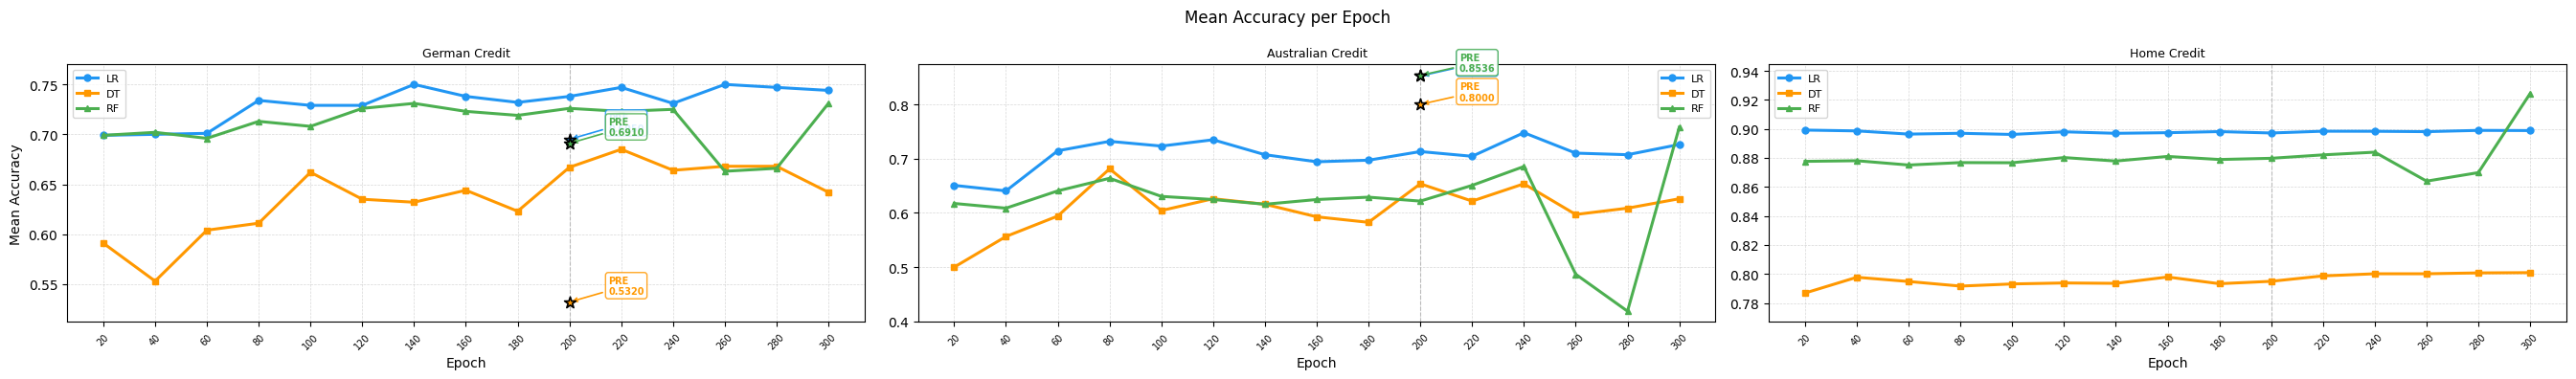

In [ ]:
plot_all_datasets({
    "German Credit":     (german_lr_results,    german_dt_results,    german_rf_results),
    "Australian Credit": (australian_lr_results, australian_dt_results, australian_rf_results),
    "Home Credit":      (home_credit_lr_results, home_credit_dt_results, home_credit_rf_results)
})

The temporal analysis of predictive accuracy across varying training epochs reveals distinct, dataset-specific learning trajectories for the GReaT generator. The observed dynamics are strongly heavily influenced by the interplay between three fundamental dataset characteristics: feature modality (mixed vs. strictly numerical), semantic complexity, and total data volume.

Home Credit Dataset (High Stability, Massive Data Volume)
The Home Credit dataset presents an extremely stable and rapid learning profile. From as early as epoch 20, the downstream predictive utility across all classifiers plateaus at levels remarkably close to the original data (e.g., Logistic Regression stabilizes around 0.898, compared to the original 0.919). This immediate convergence is primarily driven by its massive sample size (over 300,000 records) and simplified feature space (reduced to 10 strictly numerical continuous variables). The high data volume provides a dense, robust signal that allows the LLM to map the underlying continuous distributions almost instantly, mitigating variance and rendering extended training beyond 40 epochs computationally redundant.

German Credit Dataset (Moderate Stability, Semantic Complexity)
The German Credit dataset demonstrates a much more gradual and slightly volatile learning curve. For instance, the Decision Tree classifier starts relatively low at epoch 40 (0.5530) but slowly trends upward, stabilizing around epochs 180–220. This slower convergence is a direct consequence of its low data volume (approximately 1,000 samples) combined with high semantic complexity. The dataset contains a mix of numerical features and highly descriptive categorical text strings (e.g., 'Sex', 'Job', 'Housing'). Consequently, the LLM requires a significantly larger number of training epochs to simultaneously learn the semantic token representations and map their joint distributions with the numerical attributes.

Australian Credit Dataset (High Volatility, Extreme Scarcity)
The Australian Credit dataset exhibits the most erratic and unstable behavior, characterized by severe late-epoch degradation (e.g., Random Forest accuracy plummets to 0.4188 at epoch 280). This instability can be attributed to its severe data scarcity (roughly 670 samples) and its specific feature encoding. While structurally mixed, all categorical features in this dataset are encoded as numerical values (integers and floats). The combination of a tiny training set and numerically encoded categories likely confuses the underlying sequential generation mechanism, pushing the model rapidly into an overfitting regime. Prolonged training in this low-data environment leads to mode collapse and the generation of contradictory or highly artifacted samples, destroying downstream predictive utility.

Overall Observations
These findings underscore a critical takeaway for LLM-based tabular synthesis: training requirements are not strictly a function of the model architecture, but are dictated by dataset size and feature representation. Massive, homogeneous numerical datasets converge almost instantly, whereas small datasets with complex categorical text require extended training. Conversely, extremely small datasets with encoded features are highly susceptible to catastrophic overfitting, necessitating rigorous early-stopping protocols rather than relying on maximum epoch counts.

Cross-Dataset Anomaly: The Random Forest "V-Shape" Trajectory
A highly significant pattern emerges when isolating the performance of the Random Forest (RF) classifier across all three independent datasets. Regardless of data volume or structural complexity, the RF utility exhibits a synchronized anomaly in the late stages of training: relative stability up to epoch 240, followed by a severe degradation at epochs 260 and 280, concluding with an aggressive recovery and peak at epoch 300.

## 4 Discriminator

This code defines the categorical and numerical feature sets for each dataset and prepares the data for discriminator-based evaluation. The original datasets are labeled as real samples (Label = 0), while synthetic datasets generated at different GReaT training epochs are labeled as synthetic (Label = 1). For each epoch and dataset, real and synthetic data are concatenated into combined DataFrames, which serve as input for training the discriminator to assess the separability between real and synthetic distributions across training durations.

In [ ]:
original_german_categorical_features = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
original_german_numerical_features = ['Age', 'Credit amount', 'Duration']
original_australian_categorical_features = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
original_australian_numerical_features = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']
original_home_credit_categorical_features = []
original_home_credit_numerical_features = ['AMT_CREDIT', 'AMT_ANNUITY', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE']

# Feature lists for the discriminator, including the original target column as a feature
discriminator_german_categorical_features = original_german_categorical_features + ['Risk']
discriminator_german_numerical_features = original_german_numerical_features

discriminator_australian_categorical_features = original_australian_categorical_features + ['Class']
discriminator_australian_numerical_features = original_australian_numerical_features

# Home Credit 'TARGET' is a binary column (0/1), so it can be treated as categorical for the discriminator
discriminator_home_credit_categorical_features = original_home_credit_categorical_features + ['TARGET']
discriminator_home_credit_numerical_features = original_home_credit_numerical_features

# Create copies of original dataframes and add 'Label' = 0
german_df_for_discriminator = german_df.copy()
german_df_for_discriminator['Label'] = 0

australian_df_for_discriminator = australian_df.copy()
australian_df_for_discriminator['Label'] = 0

home_credit_df_for_discriminator = home_credit_df.copy()
home_credit_df_for_discriminator['Label'] = 0

epochs = ['20', '40', '60', '80', '100', '120', '140', '160', '180', '200', '220', '240', '260', '280', '300']

# Dictionaries to store combined dataframes for each dataset and epoch
german_discriminator_combined_dfs = {}
australian_discriminator_combined_dfs = {}
home_credit_discriminator_combined_dfs = {}

# German Credit
for epoch in epochs:
    synthetic_df = globals()[f'synthetic_german_{epoch}'].copy()
    synthetic_df['Label'] = 1
    german_discriminator_combined_dfs[epoch] = pd.concat([german_df_for_discriminator, synthetic_df], ignore_index=True)

# Australian Credit
for epoch in epochs:
    synthetic_df = globals()[f'synthetic_australian_{epoch}'].copy()
    synthetic_df['Label'] = 1
    australian_discriminator_combined_dfs[epoch] = pd.concat([australian_df_for_discriminator, synthetic_df], ignore_index=True)

# Home Credit
for epoch in epochs:
    synthetic_df = globals()[f'synthetic_home_credit_{epoch}'].copy()
    synthetic_df['Label'] = 1
    home_credit_discriminator_combined_dfs[epoch] = pd.concat([home_credit_df_for_discriminator, synthetic_df], ignore_index=True)

print("Combined dataframes for discriminator evaluation are ready:")
print(f"German Credit: {len(german_discriminator_combined_dfs)} dataframes (e.g., german_discriminator_combined_dfs['20'])")
print(f"Australian Credit: {len(australian_discriminator_combined_dfs)} dataframes (e.g., australian_discriminator_combined_dfs['20'])")
print(f"Home Credit: {len(home_credit_discriminator_combined_dfs)} dataframes (e.g., home_credit_discriminator_combined_dfs['20'])")


Combined dataframes for discriminator evaluation are ready:
German Credit: 15 dataframes (e.g., german_discriminator_combined_dfs['20'])
Australian Credit: 15 dataframes (e.g., australian_discriminator_combined_dfs['20'])
Home Credit: 15 dataframes (e.g., home_credit_discriminator_combined_dfs['20'])


### Preprocessing

The combined datasets are preprocessed using the same pipeline defined earlier, ensuring consistent handling of categorical and numerical features before training the discriminator.

In [ ]:
X_german_discriminator_preprocessed = {}
y_german_discriminator_preprocessed = {}
preprocessor_german_discriminator = {}

X_australian_discriminator_preprocessed = {}
y_australian_discriminator_preprocessed = {}
preprocessor_australian_discriminator = {}

X_home_credit_discriminator_preprocessed = {}
y_home_credit_discriminator_preprocessed = {}
preprocessor_home_credit_discriminator = {}

print("Preprocessing German Credit combined datasets...")
for epoch in epochs:
    combined_df = german_discriminator_combined_dfs[epoch]
    X, y, preprocessor = preprocess_dataset(
        combined_df, 'Label',
        discriminator_german_categorical_features,
        discriminator_german_numerical_features
    )
    X_german_discriminator_preprocessed[epoch] = X
    y_german_discriminator_preprocessed[epoch] = y
    preprocessor_german_discriminator[epoch] = preprocessor
print("Finished German Credit preprocessing.")

print("\nPreprocessing Australian Credit combined datasets...")
for epoch in epochs:
    combined_df = australian_discriminator_combined_dfs[epoch]
    X, y, preprocessor = preprocess_dataset(
        combined_df, 'Label',
        discriminator_australian_categorical_features,
        discriminator_australian_numerical_features
    )
    X_australian_discriminator_preprocessed[epoch] = X
    y_australian_discriminator_preprocessed[epoch] = y
    preprocessor_australian_discriminator[epoch] = preprocessor
print("Finished Australian Credit preprocessing.")

print("\nPreprocessing Home Credit combined datasets...")
for epoch in epochs:
    combined_df = home_credit_discriminator_combined_dfs[epoch]
    X, y, preprocessor = preprocess_dataset(
        combined_df, 'Label',
        discriminator_home_credit_categorical_features,
        discriminator_home_credit_numerical_features
    )
    X_home_credit_discriminator_preprocessed[epoch] = X
    y_home_credit_discriminator_preprocessed[epoch] = y
    preprocessor_home_credit_discriminator[epoch] = preprocessor
print("Finished Home Credit preprocessing.")


Preprocessing German Credit combined datasets...
Finished German Credit preprocessing.

Preprocessing Australian Credit combined datasets...
Finished Australian Credit preprocessing.

Preprocessing Home Credit combined datasets...
⚠️  INVALID DATA REMOVAL
Initial rows:      615022
Removed rows:      1
Remaining rows:    615021
Percentage removed: 0.00%

──────────────────────────────────────────────────────────────────────
PROBLEM DETAILS:

  [TOO LARGE] - 1 occurrence(s)
    Row 530367, Column 'EXT_SOURCE_2', Value: 6.6429588e+134

Finished Home Credit preprocessing.


### Evaluation of the discriminator

The discriminator (Random Forest) is trained and evaluated across multiple seeds, and the resulting accuracies are collected for each real–synthetic dataset pair.

### Discriminator's results

In [ ]:
# Initialize dictionaries to store discriminator results by epoch for the unnamed generator
german_discriminator_epoch_results = {
    epoch: [] for epoch in epochs
}
australian_discriminator_epoch_results = {
    epoch: [] for epoch in epochs
}
home_credit_discriminator_epoch_results = {
    epoch: [] for epoch in epochs
}

print("Starting discriminator training and evaluation...")
for seed in RANDOM_SEEDS:
    for epoch in epochs:
        # German Credit
        X_german_disc, y_german_disc = X_german_discriminator_preprocessed[epoch], y_german_discriminator_preprocessed[epoch]
        acc = train_and_evaluate_random_forest_discriminator(X_german_disc, y_german_disc, seed)
        german_discriminator_epoch_results[epoch].append(acc)

        # Australian Credit
        X_australian_disc, y_australian_disc = X_australian_discriminator_preprocessed[epoch], y_australian_discriminator_preprocessed[epoch]
        acc = train_and_evaluate_random_forest_discriminator(X_australian_disc, y_australian_disc, seed)
        australian_discriminator_epoch_results[epoch].append(acc)

        # Home Credit
        X_home_credit_disc, y_home_credit_disc = X_home_credit_discriminator_preprocessed[epoch], y_home_credit_discriminator_preprocessed[epoch]
        acc = train_and_evaluate_random_forest_discriminator(X_home_credit_disc, y_home_credit_disc, seed)
        home_credit_discriminator_epoch_results[epoch].append(acc)

print("Discriminator training and evaluation complete for all epochs and seeds.")


Starting discriminator training and evaluation...
Discriminator training and evaluation complete for all epochs and seeds.


In [ ]:
discriminator_epoch_table = organize_discriminator_epoch_results_for_table(
    german_discriminator_epoch_results,
    australian_discriminator_epoch_results,
    home_credit_discriminator_epoch_results
)

print("\n--- DISCRIMINATOR RESULTS TABLE: ACCURACY (Mean \u00B1 Std) ---")
display(discriminator_epoch_table)

# Save to CSV
discriminator_epoch_table.to_csv('discriminator_epoch_results.csv')
print("Discriminator results table saved to 'discriminator_epoch_results.csv'")

# Save to LaTeX
discriminator_epoch_table.to_latex('discriminator_epoch_results.tex')
print("Discriminator results table saved to 'discriminator_epoch_results.tex'")


--- DISCRIMINATOR RESULTS TABLE: ACCURACY (Mean ± Std) ---


,,20,40,60,80,100,120,140,160,180,200,220,240,260,280,300
Dataset,Model,,,,,,,,,,,,,,,
German Credit,Discriminator,0.8505 ± 0.0097,0.8525 ± 0.0149,0.8435 ± 0.0182,0.8055 ± 0.0130,0.8230 ± 0.0196,0.7955 ± 0.0089,0.8095 ± 0.0082,0.7950 ± 0.0050,0.7870 ± 0.0128,0.7890 ± 0.0058,0.7880 ± 0.0108,0.7970 ± 0.0148,0.7740 ± 0.0274,0.7620 ± 0.0119,0.7655 ± 0.0195
Australian Credit,Discriminator,0.8420 ± 0.0155,0.8333 ± 0.0219,0.8326 ± 0.0210,0.8254 ± 0.0268,0.8268 ± 0.0225,0.8058 ± 0.0233,0.8174 ± 0.0272,0.8196 ± 0.0159,0.8261 ± 0.0442,0.8167 ± 0.0338,0.7993 ± 0.0229,0.7986 ± 0.0241,0.7906 ± 0.0047,0.7812 ± 0.0297,0.7848 ± 0.0159
Home Credit,Discriminator,0.8707 ± 0.0012,0.8693 ± 0.0015,0.8701 ± 0.0014,0.8693 ± 0.0013,0.8686 ± 0.0010,0.8674 ± 0.0019,0.8679 ± 0.0010,0.8668 ± 0.0017,0.8659 ± 0.0007,0.8663 ± 0.0008,0.8653 ± 0.0007,0.8649 ± 0.0012,0.8635 ± 0.0013,0.8629 ± 0.0019,0.8618 ± 0.0009


Discriminator results table saved to 'discriminator_epoch_results.csv'
Discriminator results table saved to 'discriminator_epoch_results.tex'


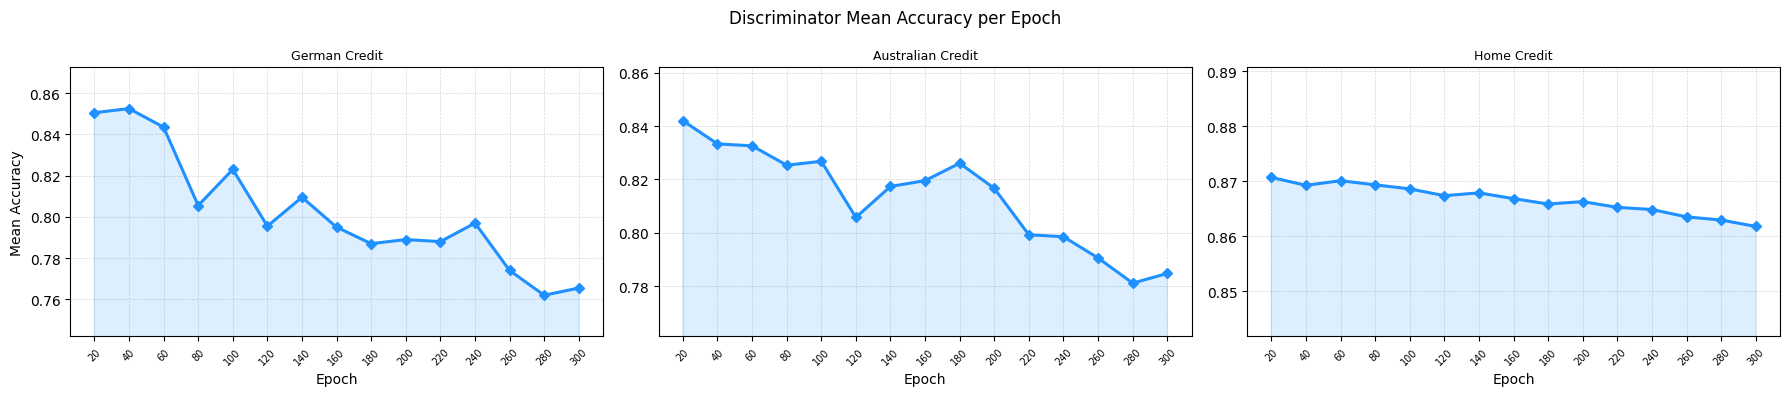

In [ ]:
plot_discriminator_all({
    "German Credit":      german_discriminator_epoch_results,
    "Australian Credit":  australian_discriminator_epoch_results,
    "Home Credit":        home_credit_discriminator_epoch_results,
})

The discriminator evaluation provides a critical secondary lens for assessing the quality of the synthetic data, directly measuring how easily a binary classifier can distinguish the generated samples from the real ones. Across all three datasets, a consistent downward trajectory in discriminator mean accuracy is observed as the number of training epochs increases. This indicates that prolonged training generally improves the distributional fidelity of the GReaT model, rendering the synthetic records progressively harder to differentiate from the empirical baseline.

Home Credit Dataset (High Stability, Persistent Detectability)
The Home Credit dataset exhibits a remarkably smooth, almost strictly linear downward trend (decaying gently from 0.8707 at epoch 20 to 0.8618 at epoch 300). As hypothesized, this extreme stability is a direct consequence of the massive sample size (~300,000 records), which acts as a powerful variance reducer during the LLM's learning process, effectively eliminating the epoch-to-epoch stochastic noise seen in the other datasets. However, despite this stability, the absolute detectability remains relatively high. This suggests that while GReaT learns the broad continuous distributions quickly, the massive volume of data also empowers the discriminator to easily detect microscopic generation artifacts (e.g., specific tokenization patterns or floating-point approximations inherent to LLM text generation) that persist regardless of training duration.

German Credit Dataset (Progressive Fidelity)
For the German Credit dataset, the discriminator accuracy shows a more pronounced decline, dropping from ~0.85 at early epochs down to ~0.76 by epoch 300. This corroborates the findings from the predictive utility analysis: learning the joint distribution of complex semantic text strings and numerical values requires substantial training time. As the model pushes past 180 epochs, its ability to generate contextually coherent and distributionally accurate categorical combinations improves significantly, increasingly fooling the discriminator.

Australian Credit Dataset (Convergence towards Memorization)
The Australian Credit dataset displays a noisy downward trend, reaching its lowest distinguishability scores at the latest epochs (e.g., 0.7812 at epoch 280 and 0.7848 at epoch 300). Crucially, this drop in discriminator accuracy aligns perfectly with the previously observed "V-shape" anomaly in the Random Forest predictive utility at these exact epochs. When interpreted jointly, a sudden drop in discriminator accuracy combined with highly erratic tree-based predictive performance strongly supports the hypothesis of late-stage mode collapse and data memorization. As the LLM begins to output near-exact replicas of the severely limited training set, the discriminator physically loses the statistical basis to separate "real" from "synthetic", resulting in artificially lower accuracy scores that mask severe overfitting.

Overall Observations
These discriminator results highlight a fundamental trade-off in tabular LLM generation. While longer training generally decreases structural detectability, the nature of this improvement is dataset-dependent. On massive datasets, stability is achieved but minor generative artifacts remain easily detectable. On extremely small datasets, a highly successful discriminator score at late epochs may not indicate perfect generation, but rather serve as a warning sign of severe data replication.

## 5 Distance to Closest Record (DCR)

In this section, we evaluate the Distance to Closest Record (DCR) metric to quantify how closely each synthetic sample matches its nearest counterpart in the original dataset. The workflow involves preprocessing the datasets to ensure comparable feature spaces, computing the DCR values for each synthetic dataset, and visualizing the results through summary plots to assess the fidelity of the generated data.

### Preprocessing

Both the original and synthetic datasets are preprocessed using column transformers to ensure a consistent feature representation. Categorical features are one-hot encoded, and numerical features are standardized, allowing the DCR computation to be performed reliably across all datasets.

In [ ]:
german_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), german_categorical_features),
        ('num', StandardScaler(), german_numerical_features)
    ])

X_german = german_preprocessor.fit_transform(german_df)

# Dictionary to store preprocessed synthetic data for each epoch
X_german_synthetic_epochs = {}
for epoch in epochs:
    synthetic_df = globals()[f'synthetic_german_{epoch}'].copy()
    X_german_synthetic_epochs[epoch] = german_preprocessor.transform(synthetic_df)

In [ ]:
australian_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), australian_categorical_features),
        ('num', StandardScaler(), australian_numerical_features)
    ])

X_australian = australian_preprocessor.fit_transform(australian_df)

# Dictionary to store preprocessed synthetic data for each epoch
X_australian_synthetic_epochs = {}
for epoch in epochs:
    synthetic_df = globals()[f'synthetic_australian_{epoch}'].copy()
    X_australian_synthetic_epochs[epoch] = australian_preprocessor.transform(synthetic_df)

In [ ]:
# Apply check_and_drop_invalid_data to the original home_credit_df to handle inf and large values
home_credit_df_clean, _ = check_and_drop_invalid_data(home_credit_df.copy(), home_credit_numerical_features, verbose=True)

home_credit_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), home_credit_categorical_features),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')), # This handles NaN values
            ('scaler', StandardScaler())
        ]), home_credit_numerical_features)
    ])

X_home_credit_dcr = home_credit_preprocessor.fit_transform(home_credit_df_clean)

# Dictionary to store preprocessed synthetic data for each epoch
X_home_credit_synthetic_epochs = {}
for epoch in epochs:
    synthetic_df = globals()[f'synthetic_home_credit_{epoch}'].copy()
    # Apply check_and_drop_invalid_data to synthetic data as well to handle inf and large values
    synthetic_df_clean, _ = check_and_drop_invalid_data(synthetic_df, home_credit_numerical_features, verbose=True)
    X_home_credit_synthetic_epochs[epoch] = home_credit_preprocessor.transform(synthetic_df_clean)


⚠️  INVALID DATA REMOVAL
Initial rows:      307511
Removed rows:      1
Remaining rows:    307510
Percentage removed: 0.00%

──────────────────────────────────────────────────────────────────────
PROBLEM DETAILS:

  [TOO LARGE] - 1 occurrence(s)
    Row 222856, Column 'EXT_SOURCE_2', Value: 6.6429588e+134



### DCR Computation

The Distance to Closest Record (DCR) is computed for each synthetic dataset relative to its corresponding original dataset. The resulting distributions are then visualized with histograms to provide a clear overview of how closely the synthetic samples resemble real data in terms of feature space proximity.

#### German Credit

In [ ]:
X_german_train, X_german_test = train_test_split(X_german, test_size=0.5, random_state=42)

# Calcola DCR tra train e test dei dati originali (baseline)
dcr_baseline_german = compute_dcr(X_german_train, X_german_test)

#### Australian Credit

In [ ]:
X_australian_train, X_australian_test = train_test_split(X_australian, test_size=0.5, random_state=42)
dcr_baseline_australian = compute_dcr(X_australian_train, X_australian_test)

#### Home Credit

In [ ]:
# DCR Computation for Home Credit
X_home_credit_train, X_home_credit_test = train_test_split(X_home_credit_dcr, test_size=0.5, random_state=42)
dcr_baseline_home_credit = compute_dcr(X_home_credit_train, X_home_credit_test)

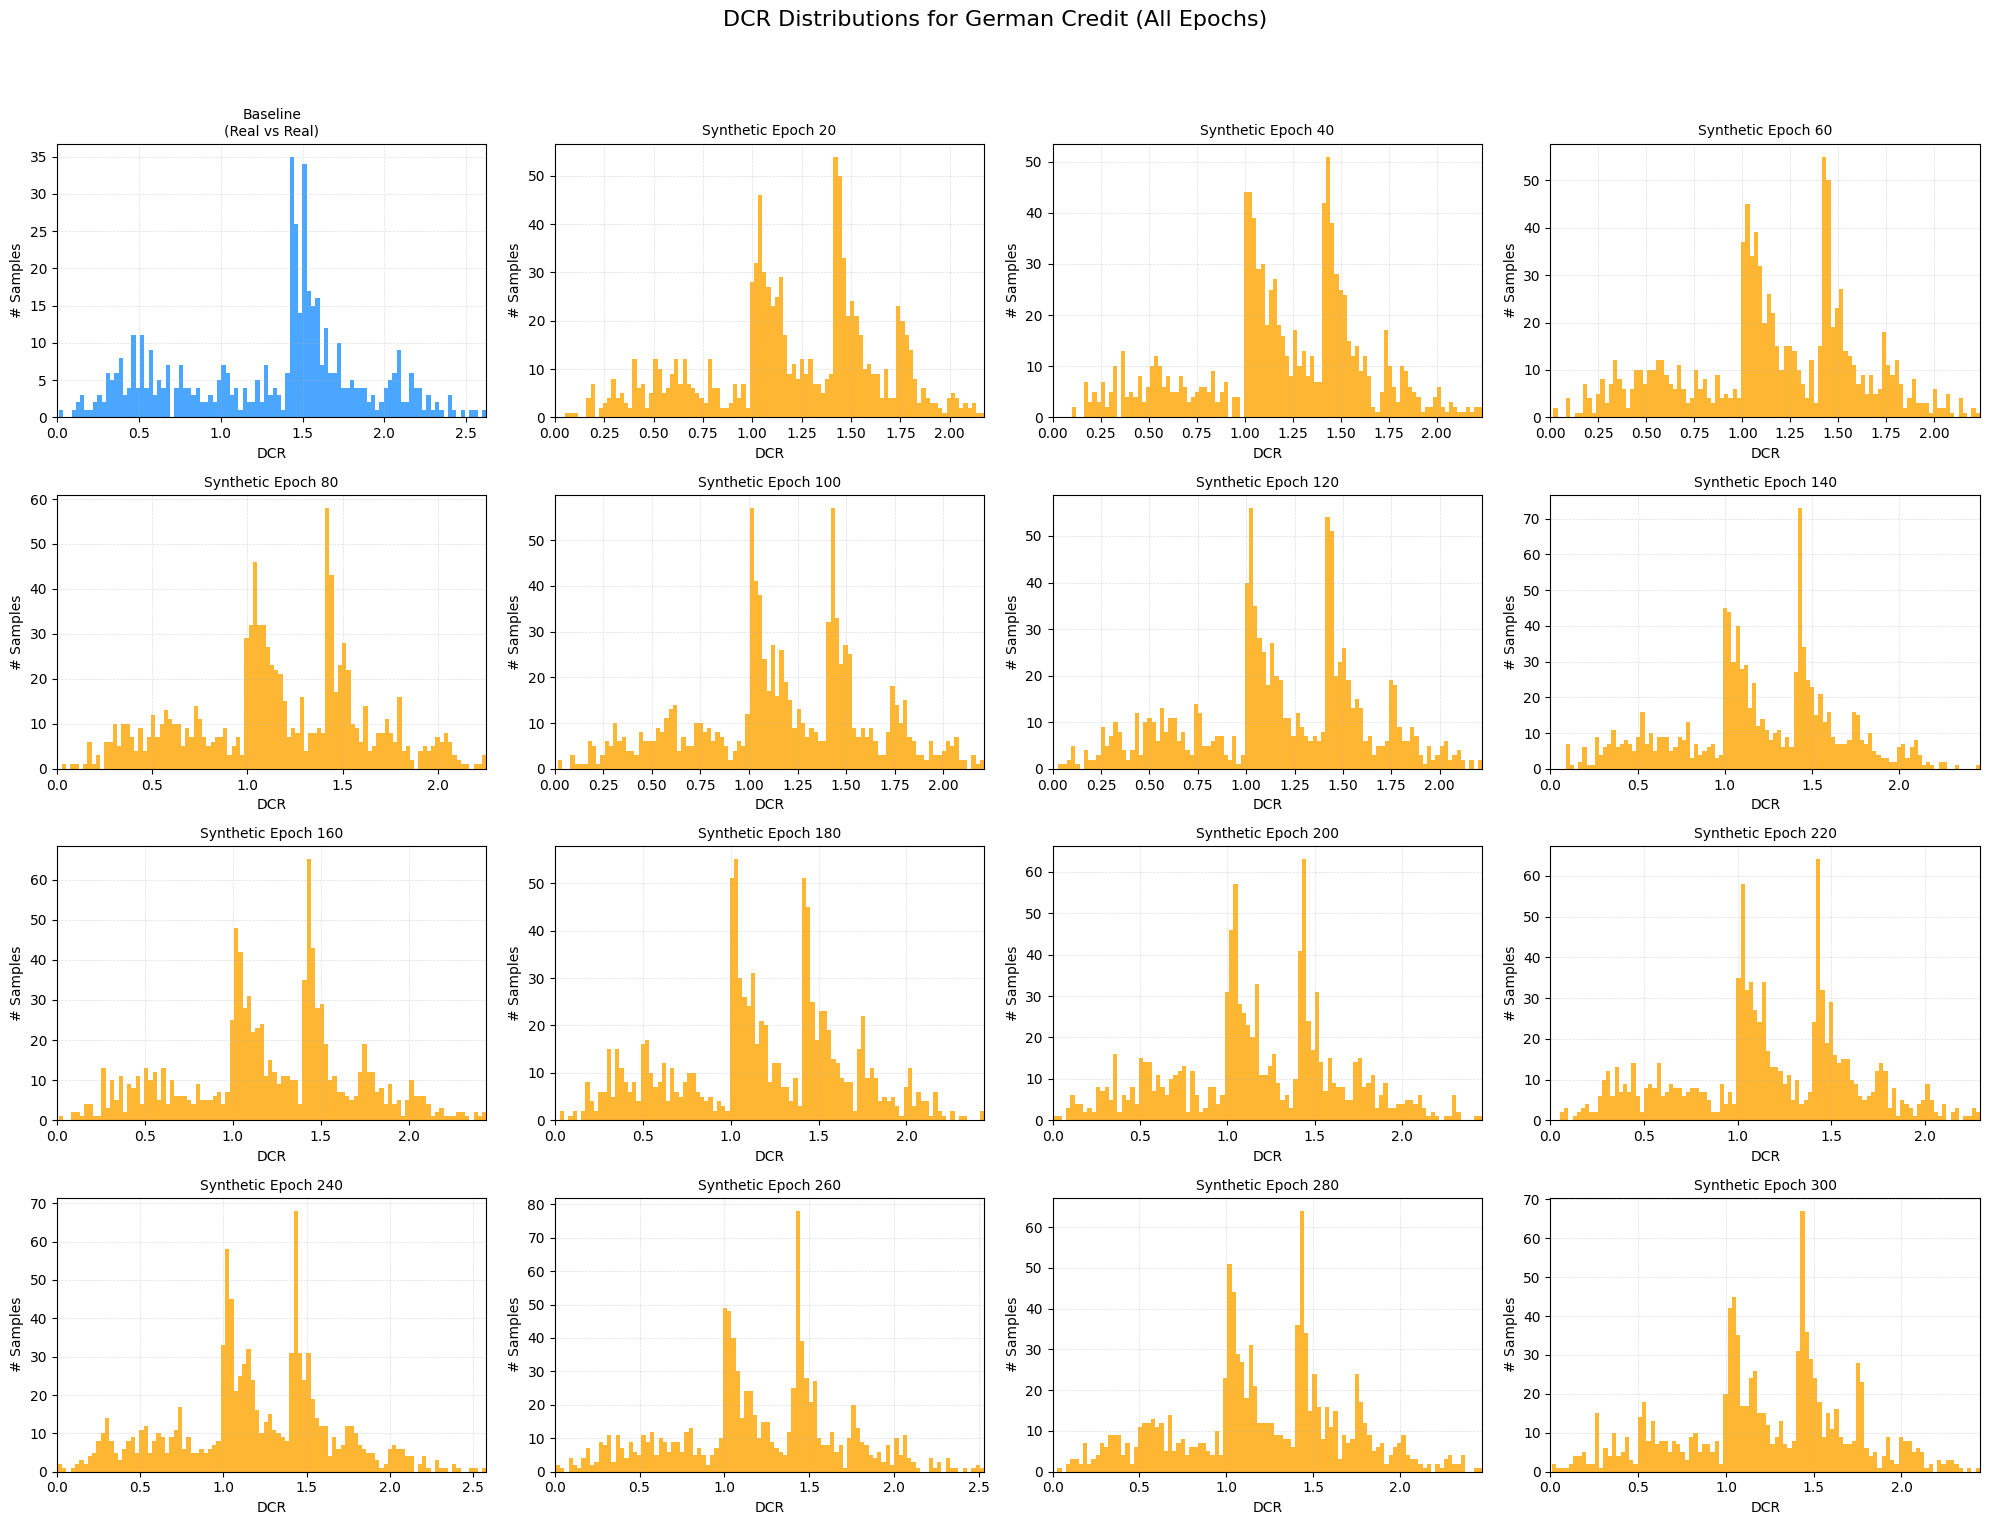

In [ ]:
german_dcr_results_by_epoch = {"Baseline\n(Real vs Real)": dcr_baseline_german}
for epoch in epochs:
    german_dcr_results_by_epoch[f"Epoch {epoch}"] = compute_dcr(X_german, X_german_synthetic_epochs[epoch])

plot_dcr_epochs(german_dcr_results_by_epoch, "German Credit", epochs, density=False)

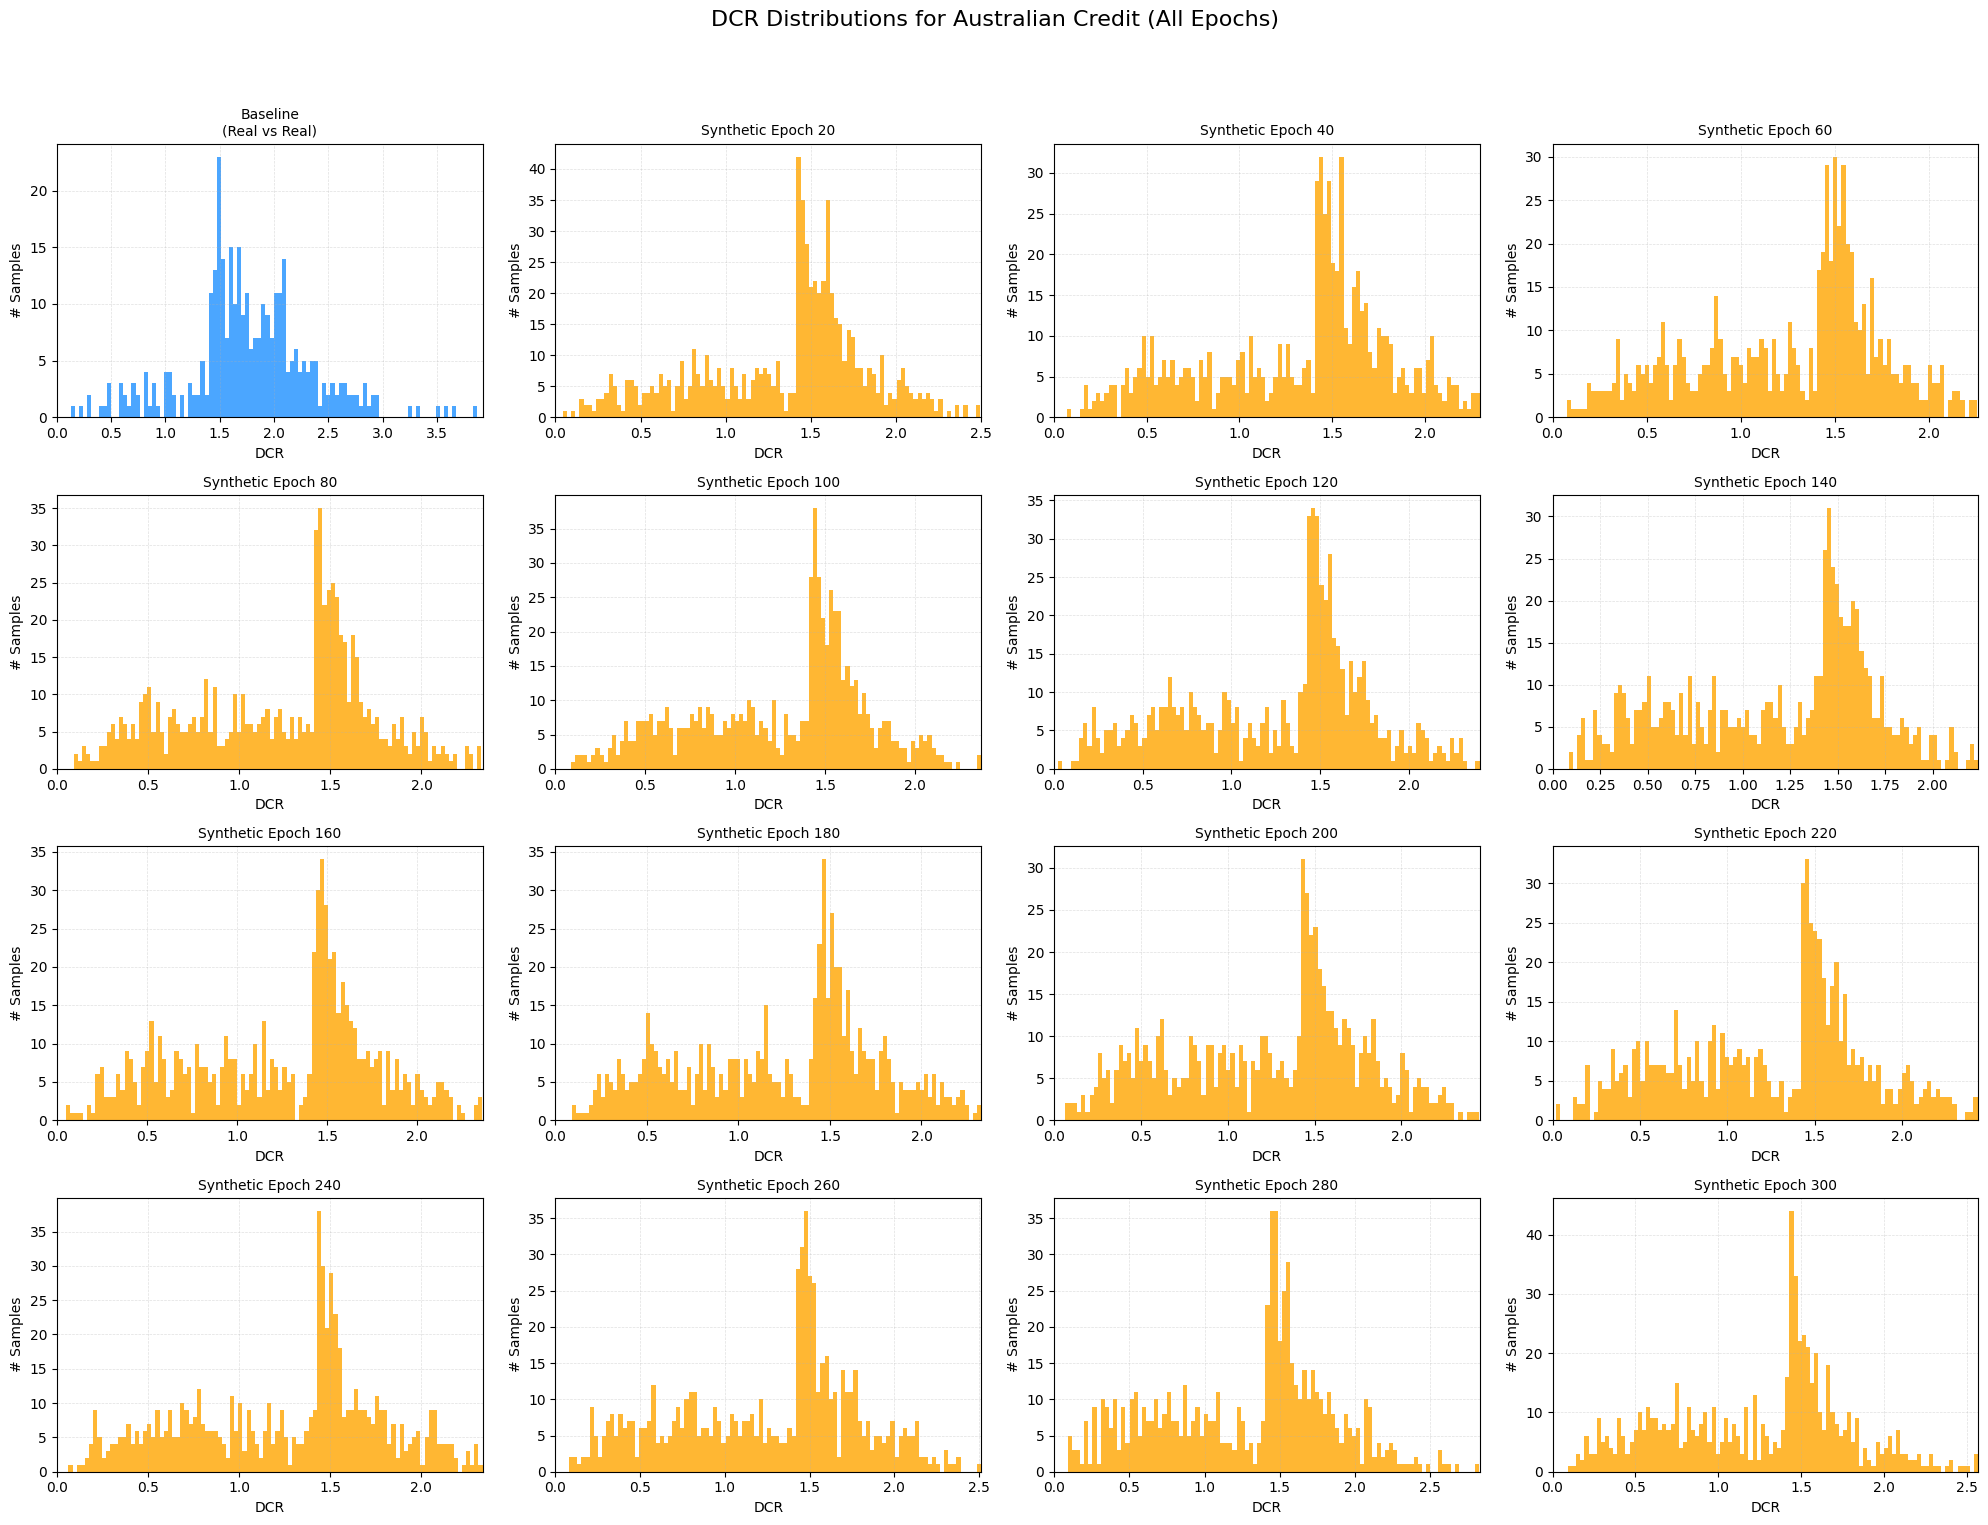

In [ ]:
australian_dcr_results_by_epoch = {"Baseline\n(Real vs Real)": dcr_baseline_australian}
for epoch in epochs:
    australian_dcr_results_by_epoch[f"Epoch {epoch}"] = compute_dcr(X_australian, X_australian_synthetic_epochs[epoch])

plot_dcr_epochs(australian_dcr_results_by_epoch, "Australian Credit", epochs, density=False)

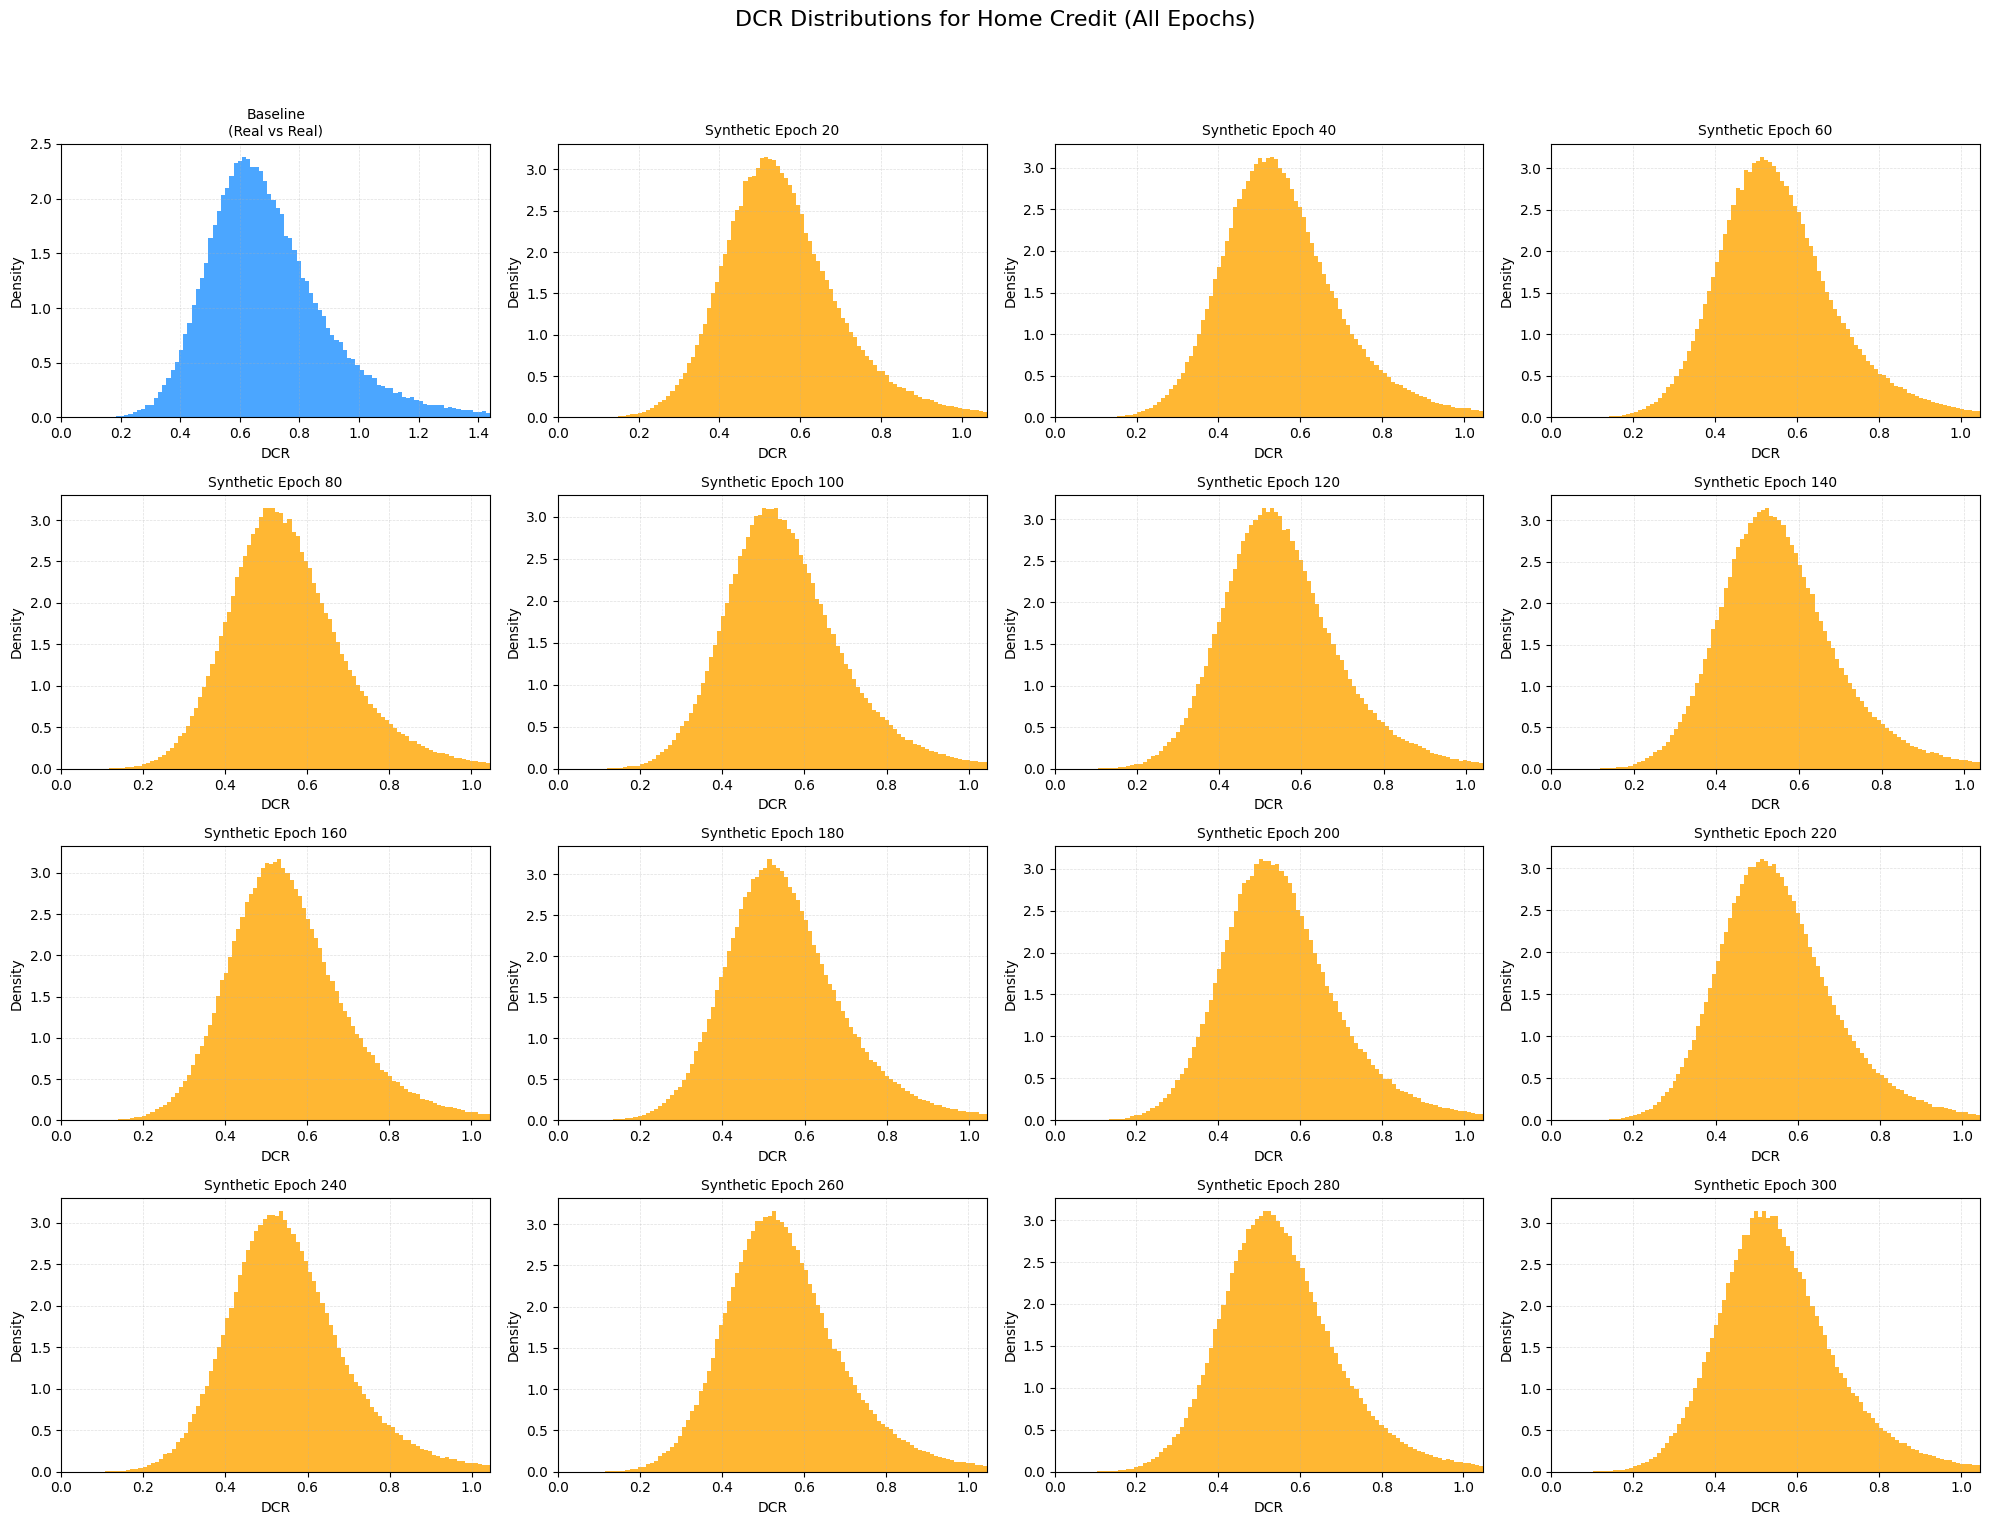

In [ ]:
home_credit_dcr_results_by_epoch = {"Baseline\n(Real vs Real)": dcr_baseline_home_credit}
for epoch in epochs:
    home_credit_dcr_results_by_epoch[f"Epoch {epoch}"] = compute_dcr(X_home_credit_dcr, X_home_credit_synthetic_epochs[epoch])

plot_dcr_epochs(home_credit_dcr_results_by_epoch, "Home Credit", epochs, density=True)

The Distance to Closest Record (DCR) metric provides essential geometric insights into how the synthetic data manifold evolves relative to the real data space over extended training epochs. A visual inspection of the DCR histograms across the three datasets reveals stark structural differences, heavily influenced by data volume and feature modalities.

Home Credit Dataset (Ideal Distributional Smoothing)
The Home Credit dataset presents an ideal generation scenario. The baseline DCR exhibits a smooth, continuous, Gaussian-like right-skewed distribution, characteristic of pairwise distances in highly populated continuous numerical spaces. Remarkably, the synthetic data replicates this exact smooth geometric profile across all evaluated epochs. As observed previously, the massive sample size (~300,000) and strictly continuous feature space "normalize" the generative process, preventing structural artifacts and ensuring consistent spatial fidelity regardless of the training duration.

German Credit Dataset (Persistent LLM Tokenization Artifacts)
For the German Credit dataset, a distinct structural anomaly is observed. While the baseline DCR shows a multi-modal spread, the synthetic distributions generated by GReaT consistently develop two dominant, sharp peaks: one around 1.5, and a highly unnatural, pronounced spike specifically at 1.0. This secondary peak at 1.0 persists across the entire training schedule (from epoch 20 to 300). This phenomenon confirms an inherent architectural inductive bias of LLM-based tabular generators: by processing tabular rows as sequential tokens, the model frequently generates synthetic records by substituting discrete textual tokens, leading to fixed, quantized Euclidean distances from the original records. Crucially, the persistence of this artifact indicates that extended training epochs cannot resolve fundamental tokenization biases in mixed-type datasets.

Australian Credit Dataset (Proximity Concentration and Overfitting)
The Australian Credit DCR distributions expose the geometric consequences of severe data scarcity. In the baseline (Real vs. Real) distribution, the pairwise distances show a broad spread extending well up to 2.0 and beyond. Conversely, the synthetic epoch distributions lose this right-side tail, unnaturally concentrating the mass around the 1.5 mark and lower. This leftward shift indicates that the synthetic samples are systematically generated too close to the empirical training records, failing to explore the broader valid data manifold. Furthermore, in the late-stage epochs (e.g., 260–300), the histograms become visibly spiky and irregular. This geometric concentration perfectly corroborates the earlier predictive and discriminative findings: constrained by a small sample size, prolonged training forces GReaT into an overfitting regime, producing tightly clustered variants of the training data rather than generalizing novel samples.

## 6 Conclusion

The temporal analysis of the GReaT generative model across varying training epochs provides critical insights into the dynamics of Large Language Model-based tabular synthesis. By jointly evaluating predictive utility, discriminator distinguishability, and DCR-based geometric fidelity, this study demonstrates that there is no universal "optimal" training schedule. Instead, the efficacy of the generative process is strictly governed by a complex trade-off between dataset volume, structural complexity, and computational expenditure.

The Data Volume and Convergence Trade-off
The most striking finding emerges from the Home Credit dataset. Characterized by a massive sample size (>300,000 records) and a strictly continuous numerical space, the model achieved near-optimal predictive utility and distributional alignment within the very first epochs (20–40). In such high-volume, low-complexity scenarios, prolonged training yields severely diminishing returns. Extending the training schedule to 300 epochs consumes significant computational time and resources without providing any measurable improvement in data quality. Therefore, for large-scale numerical datasets, early stopping is strongly recommended to optimize the cost-efficiency of the generative pipeline.

Semantic Complexity vs. Overfitting Risks
Conversely, datasets characterized by low sample volumes present a delicate optimization challenge. For the German Credit dataset, the presence of semantically rich, mixed-type textual categories demanded a significantly extended training horizon. The model required approximately 180 to 220 epochs to properly learn the joint distributions between text tokens and continuous values. However, as revealed by the DCR distributions, even prolonged training could not resolve inherent architectural biases, such as fixed-distance tokenization artifacts.

The Australian Credit dataset highlighted the severe dangers of extended training in data-scarce environments. While early-to-mid epochs produced viable synthetic samples, pushing the model beyond 240 epochs triggered catastrophic mode collapse and data replication. The sudden drop in tree-based predictive utility, combined with artificially low discriminator scores and narrowed DCR distributions, confirmed that the model transitioned from learning the underlying distribution to memorizing the sparse training data. In this scenario, excessive computational time not only wastes resources but actively degrades synthetic data quality and compromises privacy.

Final Recommendations for LLM-based Tabular Synthesis
In summary, generating high-quality tabular data using foundational LLMs requires a highly adaptive, dataset-specific approach.

Massive, numerical datasets converge rapidly; computational budgets should be minimized through aggressive early stopping.

Small, semantically complex datasets require longer training to capture feature relationships but are inherently bottlenecked by the model's tokenization mechanics.

Prolonged training is not a panacea for generation quality and actively increases the risk of overfitting and memorization in low-volume settings.

Ultimately, this research underscores that synthetic data pipelines cannot rely on arbitrary, fixed-epoch training schedules. Robust generation requires continuous checkpoint monitoring across multiple, complementary evaluation metrics—balancing downstream utility against privacy (DCR) to ensure that the computational cost invested translates into genuine distributional learning rather than memorization.